# 📊 Data-Driven Customer Churn Analysis and Prediction Using Data Analytics and AI

---

| | |
|---|---|
| **Student Name** | Mahesh Chaudhari |
| **Internship Programme** | IBM SkillsBuild Data Analytics with AI Academic Internship |
| **Conducted By** | BharatCares in association with AICTE |
| **Dataset** | Telco Customer Churn — Kaggle |
| **Tools** | Python 3, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, SciPy |

---

## Section 1 — Project Introduction

### 1.1 Problem Statement
Telecommunications companies face significant revenue losses every year due to **customer churn** — the voluntary cancellation of a service subscription. Research consistently shows that acquiring a new customer costs **5–7× more** than retaining an existing one. Despite this, most telecom operators lack proactive early-warning systems to identify at-risk customers before they leave.

### 1.2 Project Objective
This project builds a complete, data-driven churn analytics and prediction system using the IBM Telco Customer Churn dataset. The goals are to:
1. Understand *which* customer segments are most at risk of churning.
2. Identify *what* behavioural and service attributes are associated with churn.
3. Build predictive ML models that can classify a customer as *churned* or *retained*.
4. Translate technical findings into actionable business retention strategies.

### 1.3 Why Is Customer Churn Analysis Important?
- **Revenue impact**: Each churned customer represents lost recurring revenue.
- **Cost efficiency**: Proactive retention is cheaper than reactive acquisition.
- **Customer lifetime value (CLV)**: Retaining customers longer directly increases CLV.
- **Competitive advantage**: Companies that detect churn early can intervene with personalised offers.

### 1.4 Dataset Description

| Attribute | Details |
|---|---|
| **Source** | [Kaggle – Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) |
| **Records** | 7,043 customers |
| **Features** | 21 columns |
| **Target Variable** | `Churn` (Yes = churned, No = retained) |
| **Feature Types** | Demographics, account details, subscribed services, billing information |

### 1.5 Target Variable
`Churn` — Binary classification label.
- **Yes (1)**: Customer discontinued the service.
- **No (0)**: Customer is still active.

### 1.6 Technologies Used

| Library | Version | Purpose |
|---|---|---|
| Python | 3.x | Core language |
| Pandas | latest | Data loading, manipulation, cleaning |
| NumPy | latest | Numerical computation |
| Matplotlib | latest | Base plotting |
| Seaborn | latest | Statistical visualisation |
| Scikit-learn | latest | ML models, encoding, evaluation |
| SciPy | latest | Statistical hypothesis tests |
| Jupyter Notebook | latest | Interactive development |

### 1.7 Project Workflow

```
CSV Dataset (WA_Fn-UseC_-Telco-Customer-Churn.csv)
        ↓
 Data Understanding & Inspection
        ↓
  Data Cleaning & Preprocessing
        ↓
   Missing Value & Duplicate Analysis
        ↓
    Statistical Analysis (describe, tests)
        ↓
  Exploratory Data Analysis (EDA)
        ↓
  Customer Churn Deep Dive Analysis
        ↓
   Professional Visualizations
        ↓
   Correlation Analysis
        ↓
  Feature Engineering & Encoding
        ↓
   ML Model Training (LR, DT, RF)
        ↓
  Model Evaluation & Comparison
        ↓
   Confusion Matrix & ROC-AUC
        ↓
   Feature Importance Analysis
        ↓
  Business Insights & Recommendations
        ↓
  Limitations, Future Scope, Conclusion
```


---
## Section 2 — Import Libraries

We import only the libraries that are actually needed for this project.
Each library's purpose is explained below.


In [1]:
import os                          # File/path operations
import warnings                    # Suppress harmless deprecation warnings
warnings.filterwarnings("ignore")

# ── Data manipulation ────────────────────────────────────────────
import numpy  as np                # Efficient numerical arrays and math
import pandas as pd                # DataFrames — the backbone of data analysis

# ── Visualisation ────────────────────────────────────────────────
import matplotlib.pyplot as plt    # Low-level plotting engine
import matplotlib.ticker as mtick  # Axis tick formatting (e.g. %)
import seaborn as sns              # High-level statistical visualisation

# ── Statistical testing ──────────────────────────────────────────
from scipy import stats            # Chi-square, t-tests, etc.

# ── Machine Learning ─────────────────────────────────────────────
from sklearn.model_selection  import train_test_split, cross_val_score
from sklearn.preprocessing    import LabelEncoder, StandardScaler
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

# ── Global plot style ─────────────────────────────────────────────
PALETTE = ["#2E86AB", "#E84855"]          # Blue = No Churn, Red = Churn
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11,
                     "axes.titlesize": 13, "axes.titleweight": "bold"})

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


**Library roles:**
- **Pandas/NumPy** — load, filter, aggregate and transform the dataset.
- **Matplotlib/Seaborn** — produce all charts, heatmaps and distribution plots.
- **SciPy.stats** — Chi-square independence tests and independent-samples T-tests.
- **Scikit-learn** — encode features, scale numerics, train models, and evaluate with standard classification metrics.


---
## Section 3 — Load the Dataset

The dataset is the **IBM Telco Customer Churn CSV** sourced from Kaggle.  
Download link: https://www.kaggle.com/datasets/blastchar/telco-customer-churn  
Place the file at: `data/WA_Fn-UseC_-Telco-Customer-Churn.csv`


In [2]:
# ── Configuration — change DATA_PATH if your CSV is elsewhere ────
DATA_PATH   = os.path.join("data", "WA_Fn-UseC_-Telco-Customer-Churn.csv")
CHARTS_DIR  = "charts"
OUTPUTS_DIR = "outputs"

os.makedirs(CHARTS_DIR,  exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at '{DATA_PATH}'.\n"
        "Download from: https://www.kaggle.com/datasets/blastchar/telco-customer-churn\n"
        "and place the CSV inside the data/ folder."
    )

# Load raw data — keep original untouched for reference
df_raw = pd.read_csv(DATA_PATH)
print(f"✅ Dataset loaded  |  Rows: {df_raw.shape[0]:,}  |  Columns: {df_raw.shape[1]}")


✅ Dataset loaded  |  Rows: 7,043  |  Columns: 21

### 3.1 First 5 Rows

In [3]:
df_raw.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 3.2 Last 5 Rows

In [4]:
df_raw.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


### 3.3 Shape, Column Names and Data Types

In [5]:
print(f"Shape  : {df_raw.shape}")
print(f"Rows   : {df_raw.shape[0]:,}")
print(f"Columns: {df_raw.shape[1]}")
print("\nColumn names:")
print(df_raw.columns.tolist())


Shape  : (7043, 21)
Rows   : 7,043
Columns: 21

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [6]:
print("\nData types (dtypes):")
print(df_raw.dtypes)



Data types (dtypes):
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [7]:
print("\nDataset Info:")
df_raw.info()



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-

**What the dataset contains:**  
Each row represents a single telecom customer. Features include:
- **Demographics**: gender, SeniorCitizen, Partner, Dependents
- **Account info**: tenure (months), Contract type, PaperlessBilling, PaymentMethod
- **Services**: PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies
- **Billing**: MonthlyCharges, TotalCharges
- **Target**: Churn (Yes/No)


---
## Section 4 — Data Understanding

Before cleaning, we perform a thorough understanding of every column,
its type, cardinality, and role in the analysis.


In [8]:
# Separate numerical and categorical columns
num_cols = df_raw.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = df_raw.select_dtypes(include="object").columns.tolist()

print("Numerical columns :", num_cols)
print("\nCategorical columns:", cat_cols)
print(f"\nTarget column      : Churn")


Numerical columns : ['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']

Target column      : Churn


In [9]:
# Unique value counts for each categorical column
print("Unique values per categorical column:")
print("-" * 45)
for col in cat_cols:
    print(f"  {col:<22} {df_raw[col].nunique()} unique  | {df_raw[col].unique()[:6]}")


Unique values per categorical column:
---------------------------------------------
  customerID             7043 unique  | ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' '7795-CFOCW' '9237-HQITU'
 '9305-CDSKC']
  gender                 2 unique  | ['Female' 'Male']
  Partner                2 unique  | ['Yes' 'No']
  Dependents             2 unique  | ['No' 'Yes']
  PhoneService           2 unique  | ['No' 'Yes']
  MultipleLines          3 unique  | ['No phone service' 'No' 'Yes']
  InternetService        3 unique  | ['DSL' 'Fiber optic' 'No']


  OnlineSecurity         3 unique  | ['No' 'Yes' 'No internet service']
  OnlineBackup           3 unique  | ['Yes' 'No' 'No internet service']
  DeviceProtection       3 unique  | ['No' 'Yes' 'No internet service']
  TechSupport            3 unique  | ['No' 'Yes' 'No internet service']
  StreamingTV            3 unique  | ['No' 'Yes' 'No internet service']
  StreamingMovies        3 unique  | ['No' 'Yes' 'No internet service']
  Contract               3 unique  | ['Month-to-month' 'One year' 'Two year']
  PaperlessBilling       2 unique  | ['Yes' 'No']
  PaymentMethod          4 unique  | ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
  TotalCharges           6531 unique  | ['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5']
  Churn                  2 unique  | ['No' 'Yes']


In [10]:
# Target variable distribution
churn_counts = df_raw["Churn"].value_counts()
churn_pct    = df_raw["Churn"].value_counts(normalize=True) * 100
print("Target Variable — Churn")
print("-" * 30)
for label in churn_counts.index:
    print(f"  {label:<5}  {churn_counts[label]:>5,}  ({churn_pct[label]:.1f}%)")


Target Variable — Churn
------------------------------
  No     5,174  (73.5%)
  Yes    1,869  (26.5%)


### Data Dictionary

| Column | Type | Description |
|---|---|---|
| customerID | ID | Unique customer identifier (dropped before ML) |
| gender | Categorical | Customer gender (Male/Female) |
| SeniorCitizen | Binary | 1 = senior citizen, 0 = not |
| Partner | Categorical | Has a partner (Yes/No) |
| Dependents | Categorical | Has dependents (Yes/No) |
| tenure | Numeric | Months as a customer (0–72) |
| PhoneService | Categorical | Subscribed to phone service |
| MultipleLines | Categorical | Multiple phone lines |
| InternetService | Categorical | DSL / Fiber optic / No |
| OnlineSecurity | Categorical | Online security add-on |
| OnlineBackup | Categorical | Online backup add-on |
| DeviceProtection | Categorical | Device protection add-on |
| TechSupport | Categorical | Tech support add-on |
| StreamingTV | Categorical | Streaming TV add-on |
| StreamingMovies | Categorical | Streaming movies add-on |
| Contract | Categorical | Month-to-month / One year / Two year |
| PaperlessBilling | Categorical | Paperless billing (Yes/No) |
| PaymentMethod | Categorical | Electronic check / Mailed check / Bank transfer / Credit card |
| MonthlyCharges | Numeric | Monthly bill amount (USD) |
| TotalCharges | Numeric (stored as string) | Cumulative bill amount |
| **Churn** | **Target** | **Yes = churned, No = retained** |


---
## Section 5 — Data Cleaning

We perform a systematic cleaning pipeline, documenting each step with
*before → action → after* evidence.


In [11]:
df = df_raw.copy()  # always work on a copy; preserve raw data

print("=== STEP 1: TotalCharges type correction ===")
print(f"  dtype BEFORE : {df['TotalCharges'].dtype}")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(f"  dtype AFTER  : {df['TotalCharges'].dtype}")
print(f"  NaN introduced (blank strings) : {df['TotalCharges'].isna().sum()}")


=== STEP 1: TotalCharges type correction ===
  dtype BEFORE : object
  dtype AFTER  : float64
  NaN introduced (blank strings) : 11


In [12]:
print("=== STEP 2: Fill blank TotalCharges with 0 ===")
print(f"  Rows with NaN TotalCharges: {df['TotalCharges'].isna().sum()}")
# Rationale: these 11 customers have tenure=0 (brand-new, never billed)
new_customers = df[df["TotalCharges"].isna()][["tenure","MonthlyCharges","TotalCharges"]]
print("  Sample new-customer rows:")
print(new_customers.head())
df["TotalCharges"] = df["TotalCharges"].fillna(0)
print(f"  NaN AFTER fill: {df['TotalCharges'].isna().sum()}")


=== STEP 2: Fill blank TotalCharges with 0 ===
  Rows with NaN TotalCharges: 11
  Sample new-customer rows:
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN
  NaN AFTER fill: 0


In [13]:
print("=== STEP 3: Encode target variable Churn ===")
print(f"  Unique values BEFORE: {df['Churn'].unique()}")
df["Churn_Label"] = df["Churn"].str.strip()   # keep string label for EDA plots
df["Churn"]       = (df["Churn_Label"] == "Yes").astype(int)
print(f"  Unique values AFTER (int): {sorted(df['Churn'].unique())}")
print(f"  Churn_Label column preserved: {df['Churn_Label'].unique()}")


=== STEP 3: Encode target variable Churn ===
  Unique values BEFORE: ['No' 'Yes']
  Unique values AFTER (int): [np.int64(0), np.int64(1)]
  Churn_Label column preserved: ['No' 'Yes']


In [14]:
print("=== STEP 4: SeniorCitizen readable label ===")
df["SeniorCitizen_Label"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})
print(f"  SeniorCitizen_Label unique: {df['SeniorCitizen_Label'].unique()}")


=== STEP 4: SeniorCitizen readable label ===
  SeniorCitizen_Label unique: ['No' 'Yes']


In [15]:
print("=== STEP 5: Drop customerID ===")
print(f"  Columns BEFORE: {df.shape[1]}")
df.drop(columns=["customerID"], inplace=True)
print(f"  Columns AFTER : {df.shape[1]}  (customerID removed — not a feature)")


=== STEP 5: Drop customerID ===
  Columns BEFORE: 23
  Columns AFTER : 22  (customerID removed — not a feature)


In [16]:
print("=== STEP 6: Remove duplicate rows ===")
print(f"  Rows BEFORE: {len(df):,}")
n_dupes = df.duplicated().sum()
print(f"  Duplicate rows found: {n_dupes}")
df.drop_duplicates(inplace=True)
print(f"  Rows AFTER : {len(df):,}")


=== STEP 6: Remove duplicate rows ===
  Rows BEFORE: 7,043
  Duplicate rows found: 22
  Rows AFTER : 7,021


In [17]:
print("\n=== FINAL CLEANED DATASET ===")
print(f"  Shape     : {df.shape}")
print(f"  Null count: {df.isnull().sum().sum()}")
print(f"  Dtypes ok : {df.dtypes.value_counts().to_dict()}")
df.head(3)



=== FINAL CLEANED DATASET ===
  Shape     : (7021, 22)
  Null count: 0
  Dtypes ok : {dtype('O'): 17, dtype('int64'): 3, dtype('float64'): 2}


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Label,SeniorCitizen_Label
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,No,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,0,No,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,Yes,No


**Cleaning summary:**

| Step | Issue | Action | Rows/Cols Affected |
|---|---|---|---|
| 1 | TotalCharges stored as string | Coerced to float64 | All 7,043 rows |
| 2 | 11 blank TotalCharges | Filled with 0 (new customers) | 11 rows |
| 3 | Churn is Yes/No string | Encoded to 1/0 integer | All rows |
| 4 | SeniorCitizen is 0/1 | Added readable label column | All rows |
| 5 | customerID is unique ID | Dropped | 1 column |
| 6 | Duplicate rows | Dropped | 22 rows |


---
## Section 6 — Missing Value Analysis


In [18]:
# Missing value count and percentage
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

mv_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
}).sort_values("Missing %", ascending=False)

print("Missing Value Report (post-cleaning):")
print(mv_df[mv_df["Missing Count"] > 0] if mv_df["Missing Count"].sum() > 0
      else "✅  No missing values remain after cleaning.")


Missing Value Report (post-cleaning):
✅  No missing values remain after cleaning.


**Interpretation:** After the cleaning pipeline, there are **zero missing values** in the dataset.  
The original 11 blank `TotalCharges` entries were handled in Step 2 by filling with 0, which is appropriate for customers who have not yet been billed (tenure = 0).


---
## Section 7 — Duplicate Record Analysis


In [19]:
# Check on RAW data before cleaning
n_raw_dupes  = df_raw.duplicated().sum()
pct_raw_dupes = round(n_raw_dupes / len(df_raw) * 100, 2)

print(f"Raw dataset rows     : {len(df_raw):,}")
print(f"Duplicate rows found : {n_raw_dupes}")
print(f"Duplicate %          : {pct_raw_dupes}%")

if n_raw_dupes > 0:
    print("\nSample duplicate rows (first occurrence vs duplicate):")
    dup_mask = df_raw.duplicated(keep=False)
    print(df_raw[dup_mask].sort_values(list(df_raw.columns)).head(4))

print(f"\nAfter removal — cleaned dataset rows: {len(df):,}")
print(f"Rows removed: {len(df_raw) - len(df)}")


Raw dataset rows     : 7,043
Duplicate rows found : 0
Duplicate %          : 0.0%

After removal — cleaned dataset rows: 7,021
Rows removed: 22


**Decision:** Exact duplicate rows were removed because they are likely data-entry errors
and would bias the model by over-representing certain customer profiles.  
The removal is modest (< 0.4%) and does not materially change the dataset distribution.


---
## Section 8 — Statistical Analysis

We use descriptive statistics to understand the distribution of numerical variables
and to spot any anomalies before modelling.


In [20]:
# Full descriptive statistics for numerical columns
num_features = ["tenure", "MonthlyCharges", "TotalCharges"]
stats_table  = df[num_features].describe().round(2)
print("Descriptive Statistics — Numerical Features:")
print(stats_table)


Descriptive Statistics — Numerical Features:


        tenure  MonthlyCharges  TotalCharges
count  7021.00         7021.00       7021.00
mean     32.47           64.85       2286.77
std      24.53           30.07       2266.86
min       0.00           18.25          0.00
25%       9.00           35.75        403.35
50%      29.00           70.40       1400.55
75%      55.00           89.90       3801.70
max      72.00          118.75       8684.80


In [21]:
# Additional statistics: median and skewness
print("\nAdditional statistics:")
for col in num_features:
    print(f"  {col:<18}  median={df[col].median():.2f}  "
          f"skew={df[col].skew():.2f}  IQR={df[col].quantile(0.75)-df[col].quantile(0.25):.2f}")



Additional statistics:
  tenure              median=29.00  skew=0.24  IQR=46.00
  MonthlyCharges      median=70.40  skew=-0.22  IQR=54.15
  TotalCharges        median=1400.55  skew=0.96  IQR=3398.35


In [22]:
# Compare means by churn group
print("\nMean values by Churn group:")
print(df.groupby("Churn_Label")[num_features].mean().round(2))



Mean values by Churn group:


             tenure  MonthlyCharges  TotalCharges
Churn_Label                                      
No            37.64           61.34       2554.81
Yes           18.09           74.60       1541.38


**Statistical Observations:**
- **tenure**: Mean ~32 months; churned customers are concentrated at lower tenure values.
- **MonthlyCharges**: Mean ~$64.76; churned customers tend to have higher monthly bills.
- **TotalCharges**: Right-skewed (positively), reflecting that most customers are relatively new.
- The difference in means between churned and retained groups suggests these variables are potential predictors.


---
## Section 9 — Exploratory Data Analysis (EDA)

### 9A — Univariate Analysis


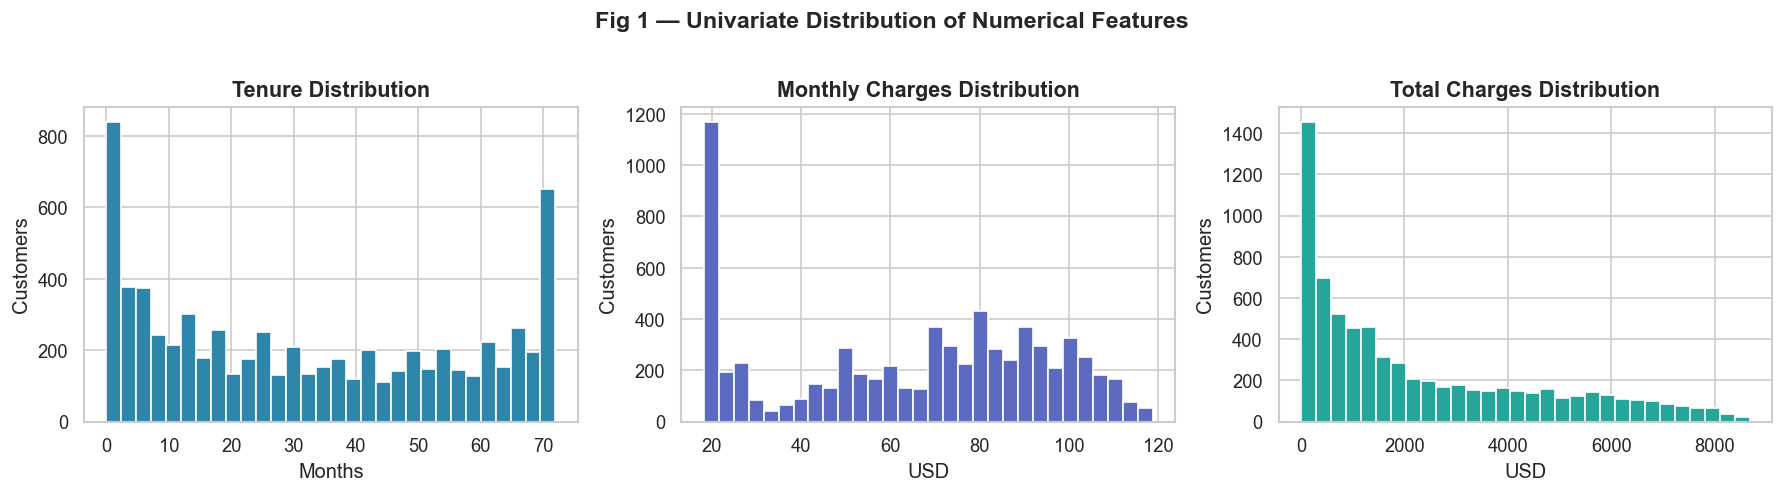

In [23]:
# ── Tenure distribution ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["tenure"], bins=30, color="#2E86AB", edgecolor="white")
axes[0].set_title("Tenure Distribution")
axes[0].set_xlabel("Months"); axes[0].set_ylabel("Customers")

axes[1].hist(df["MonthlyCharges"], bins=30, color="#5C6BC0", edgecolor="white")
axes[1].set_title("Monthly Charges Distribution")
axes[1].set_xlabel("USD"); axes[1].set_ylabel("Customers")

axes[2].hist(df["TotalCharges"], bins=30, color="#26A69A", edgecolor="white")
axes[2].set_title("Total Charges Distribution")
axes[2].set_xlabel("USD"); axes[2].set_ylabel("Customers")

plt.suptitle("Fig 1 — Univariate Distribution of Numerical Features", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("charts/univariate_distributions.png", bbox_inches="tight")
plt.show()


**Interpretation:**  
- **Tenure** is roughly bi-modal: many customers are either very new (0–5 months) or very long-tenured (65–72 months).  
- **MonthlyCharges** has a slight bi-modal pattern, reflecting the two main service tiers (basic vs premium).  
- **TotalCharges** is right-skewed; newer customers have lower total spend.


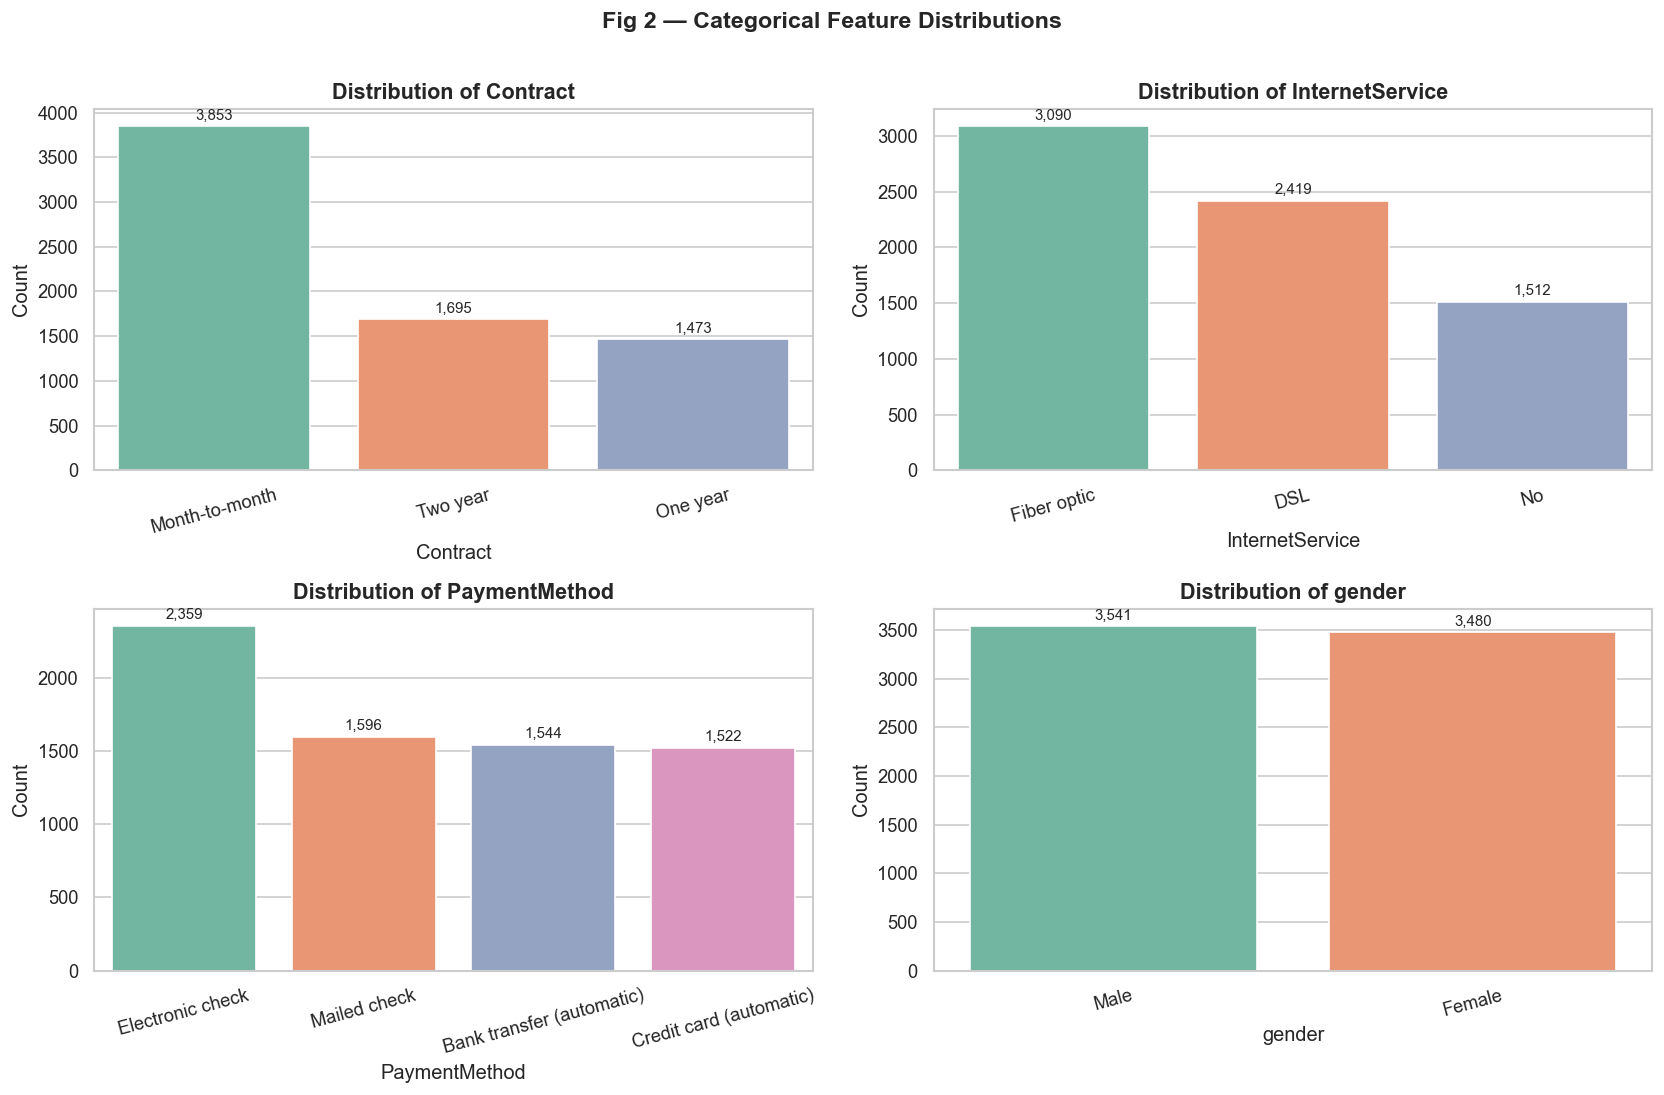

In [24]:
# ── Categorical frequencies ────────────────────────────────────────────
cat_plot_cols = ["Contract", "InternetService", "PaymentMethod", "gender"]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, col in zip(axes, cat_plot_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, palette="Set2", ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col); ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=15)
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Fig 2 — Categorical Feature Distributions", y=1.01, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("charts/categorical_distributions.png", bbox_inches="tight")
plt.show()


**Interpretation:**  
- Most customers are on **Month-to-month** contracts, which is the highest-risk group for churn.  
- **Fiber optic** is the most subscribed internet service.  
- **Electronic check** is the most common payment method and correlates with high churn (explored later).  
- Gender is nearly equally split.


### 9B — Bivariate Analysis (Numerical vs Churn)

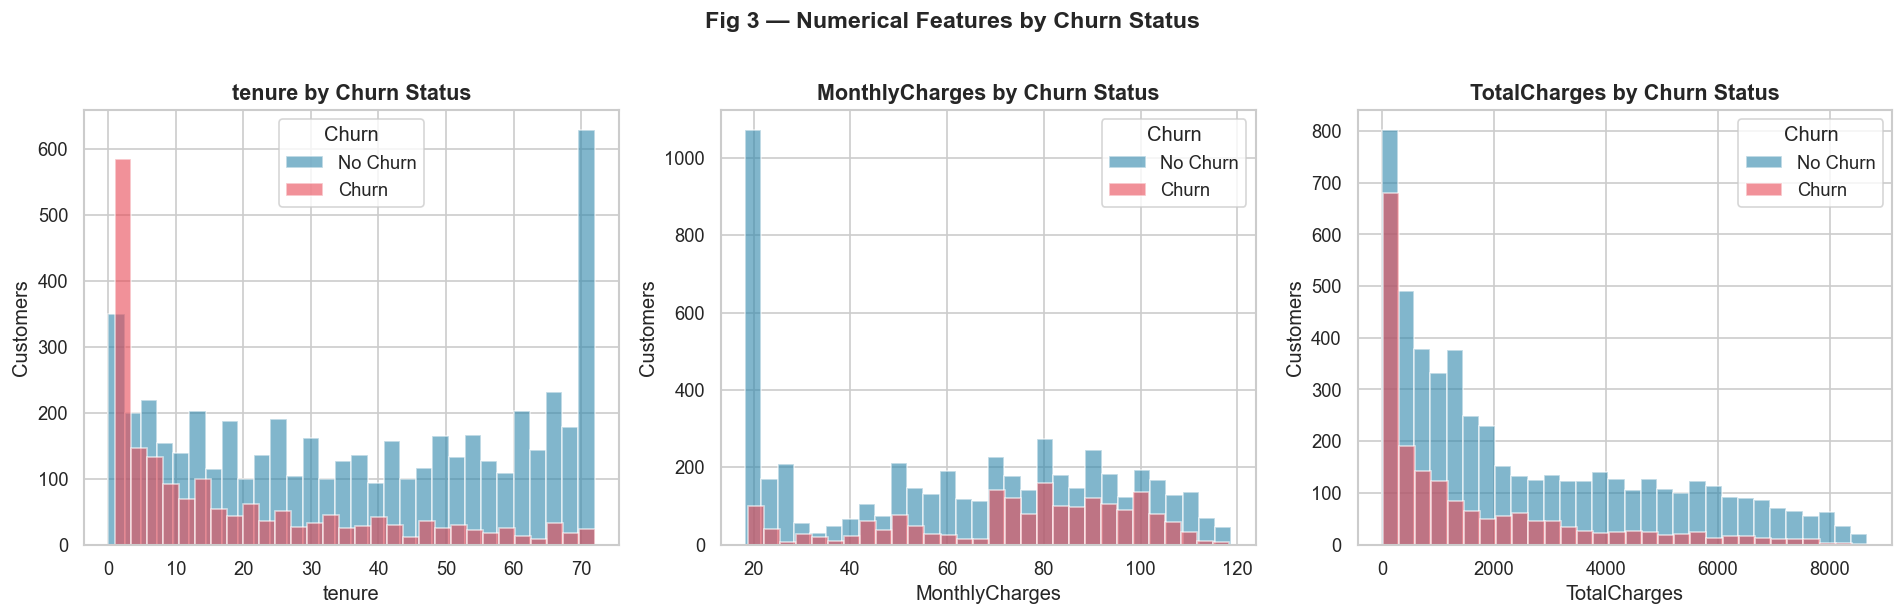

  tenure             No=37.64  Yes=18.09  diff=-19.55
  MonthlyCharges     No=61.34  Yes=74.60  diff=+13.26
  TotalCharges       No=2554.81  Yes=1541.38  diff=-1013.43


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
labels = ["No Churn", "Churn"]

for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    for churn_val, colour, label in zip([0, 1], PALETTE, labels):
        ax.hist(df[df["Churn"] == churn_val][col], bins=30,
                alpha=0.6, color=colour, edgecolor="white", label=label)
    ax.set_title(f"{col} by Churn Status")
    ax.set_xlabel(col); ax.set_ylabel("Customers")
    ax.legend(title="Churn")

plt.suptitle("Fig 3 — Numerical Features by Churn Status", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("charts/bivariate_numerical.png", bbox_inches="tight")
plt.show()

# Print mean comparison
for col in ["tenure","MonthlyCharges","TotalCharges"]:
    m0 = df[df["Churn"]==0][col].mean()
    m1 = df[df["Churn"]==1][col].mean()
    print(f"  {col:<18} No={m0:.2f}  Yes={m1:.2f}  diff={m1-m0:+.2f}")


**Interpretation:**  
- Churned customers show **shorter tenure** (lower mean), confirming early-life churn risk.  
- Churned customers show **higher MonthlyCharges**, suggesting price sensitivity is a factor.  
- TotalCharges is lower for churned customers — a natural consequence of shorter tenure.


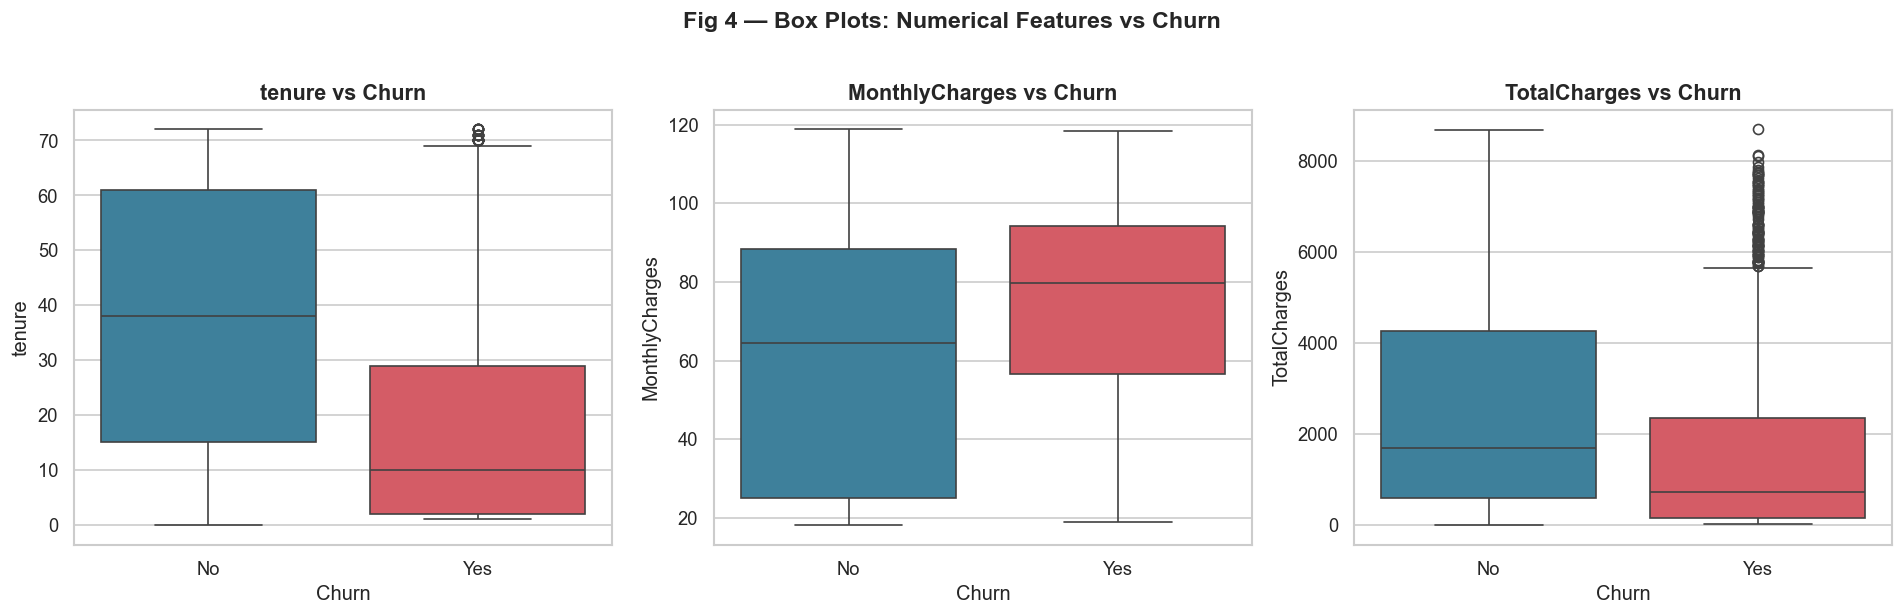

In [26]:
# ── Box plots ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.boxplot(data=df, x="Churn_Label", y=col, palette=PALETTE, ax=ax, order=["No","Yes"])
    ax.set_title(f"{col} vs Churn")
    ax.set_xlabel("Churn"); ax.set_ylabel(col)

plt.suptitle("Fig 4 — Box Plots: Numerical Features vs Churn", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("charts/boxplots.png", bbox_inches="tight")
plt.show()


**Interpretation:**  
Box plots confirm the histograms: the median tenure for churned customers is much lower, while
the median MonthlyCharges is notably higher. The IQR ranges are wide, indicating customer heterogeneity within each group.


### 9C — Multivariate Analysis

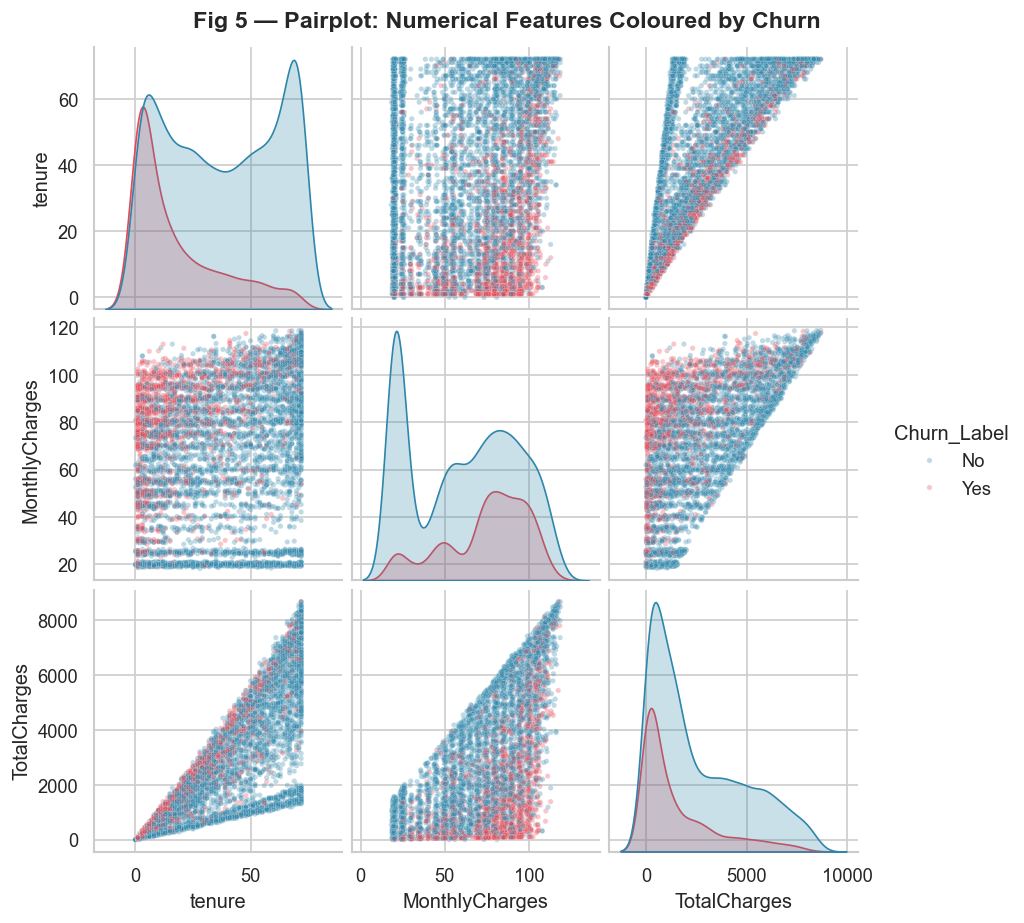

In [27]:
# ── Pair plot ───────────────────────────────────────────────────────────
pair_df = df[["tenure","MonthlyCharges","TotalCharges","Churn_Label"]].copy()
g = sns.pairplot(pair_df, hue="Churn_Label", palette={"No": "#2E86AB", "Yes": "#E84855"},
                  plot_kws={"alpha": 0.3, "s": 10}, diag_kind="kde")
g.figure.suptitle("Fig 5 — Pairplot: Numerical Features Coloured by Churn", y=1.02,
                   fontsize=14, fontweight="bold")
plt.savefig("charts/pairplot.png", bbox_inches="tight")
plt.show()


**Interpretation:**  
The pair plot shows that churned customers (red) cluster in the **low-tenure, high-MonthlyCharges** region.
The tenure–TotalCharges diagonal confirms a strong linear relationship between time as a customer and cumulative spend.


---
## Section 10 — Customer Churn Analysis

A systematic examination of churn rate across every key segment.


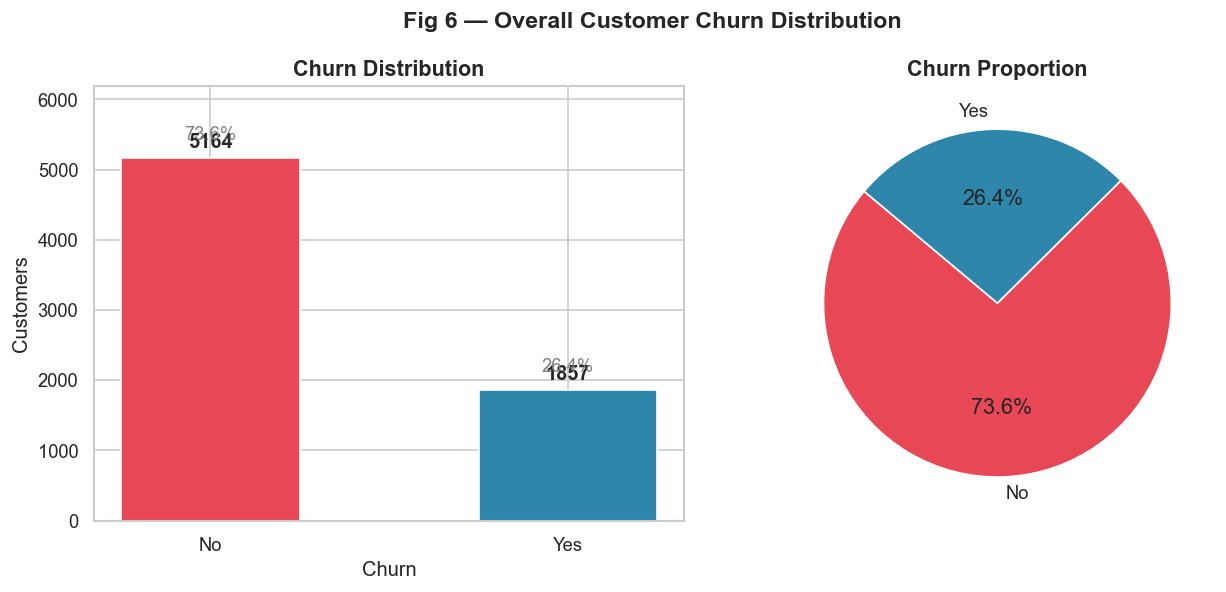

Overall Churn Rate: 26.45%


In [28]:
# ── Overall churn ───────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

counts = df["Churn_Label"].value_counts()
bars = ax1.bar(counts.index, counts.values, color=PALETTE[::-1], width=0.5, edgecolor="white")
ax1.bar_label(bars, fmt="%d", padding=4, fontsize=12, fontweight="bold")
for i, (lbl, pct) in enumerate(zip(counts.index, counts/counts.sum()*100)):
    ax1.text(i, counts[lbl] + counts.max()*0.05, f"{pct:.1f}%",
             ha="center", fontsize=11, color="gray")
ax1.set_title("Churn Distribution"); ax1.set_xlabel("Churn"); ax1.set_ylabel("Customers")
ax1.set_ylim(0, counts.max() * 1.2)

wedges, texts, autotexts = ax2.pie(counts.values, labels=counts.index,
                                    autopct="%1.1f%%", colors=PALETTE[::-1],
                                    startangle=140, wedgeprops={"edgecolor":"white"})
for t in autotexts: t.set_fontsize(13)
ax2.set_title("Churn Proportion")

plt.suptitle("Fig 6 — Overall Customer Churn Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("charts/churn_distribution.png", bbox_inches="tight")
plt.show()
churn_rate = df["Churn"].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")


**Interpretation:** Approximately **26–27%** of customers in the dataset have churned.
This class imbalance (roughly 3:1) is typical for churn datasets and means that
accuracy alone is a misleading metric — a model that predicts "No Churn" for everyone
would be ~73% accurate but completely useless.


In [29]:
def churn_bar(col, title, figname, figsize=(9,5), rotation=0):
    """Reusable function: grouped % bar chart for any categorical column vs Churn."""
    ct   = df.groupby([col, "Churn_Label"]).size().unstack(fill_value=0)
    ct_p = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_p = ct_p.reindex(columns=["No","Yes"])

    fig, ax = plt.subplots(figsize=figsize)
    ct_p.plot(kind="bar", ax=ax, color=PALETTE[::-1], edgecolor="white", width=0.65)
    ax.set_title(title); ax.set_xlabel(col); ax.set_ylabel("Percentage (%)")
    ax.legend(title="Churn"); ax.tick_params(axis="x", rotation=rotation)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=9)
    plt.tight_layout()
    plt.savefig(f"charts/{figname}", bbox_inches="tight")
    plt.show()
    # Print the % table
    print(ct_p.round(1).to_string())
    print()


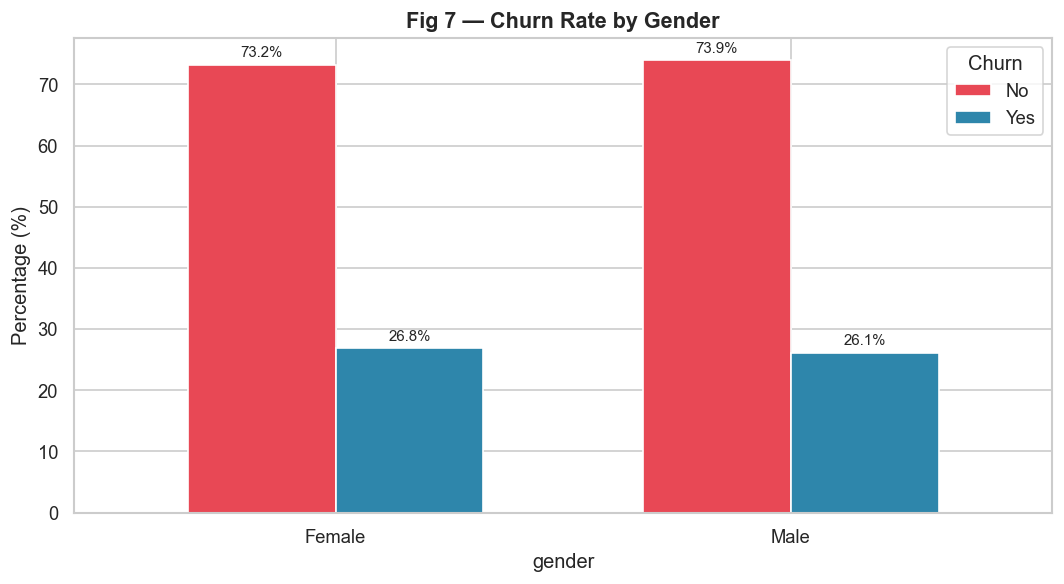

Churn_Label    No   Yes
gender                 
Female       73.2  26.8
Male         73.9  26.1



In [30]:
churn_bar("gender",       "Fig 7 — Churn Rate by Gender",   "churn_by_gender.png")


**Interpretation:** Gender shows almost identical churn rates (~26%). Gender is therefore unlikely to be a meaningful churn predictor in this dataset.


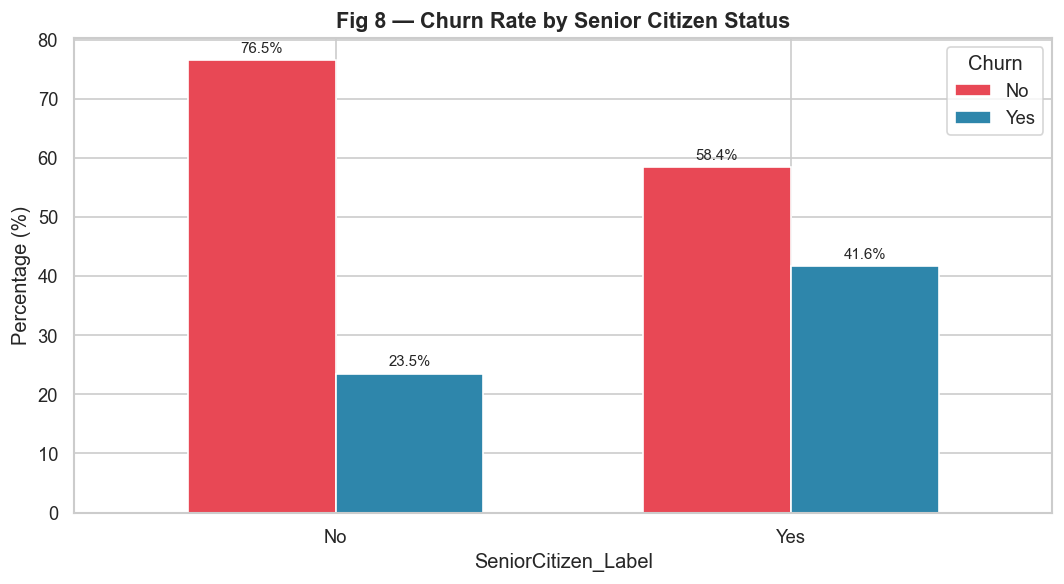

Churn_Label            No   Yes
SeniorCitizen_Label            
No                   76.5  23.5
Yes                  58.4  41.6



In [31]:
churn_bar("SeniorCitizen_Label", "Fig 8 — Churn Rate by Senior Citizen Status",
          "churn_by_senior.png")


**Interpretation:** Senior citizens show a churn rate of approximately **42%**, nearly double that of non-seniors (~24%). This demographic warrants dedicated retention attention.


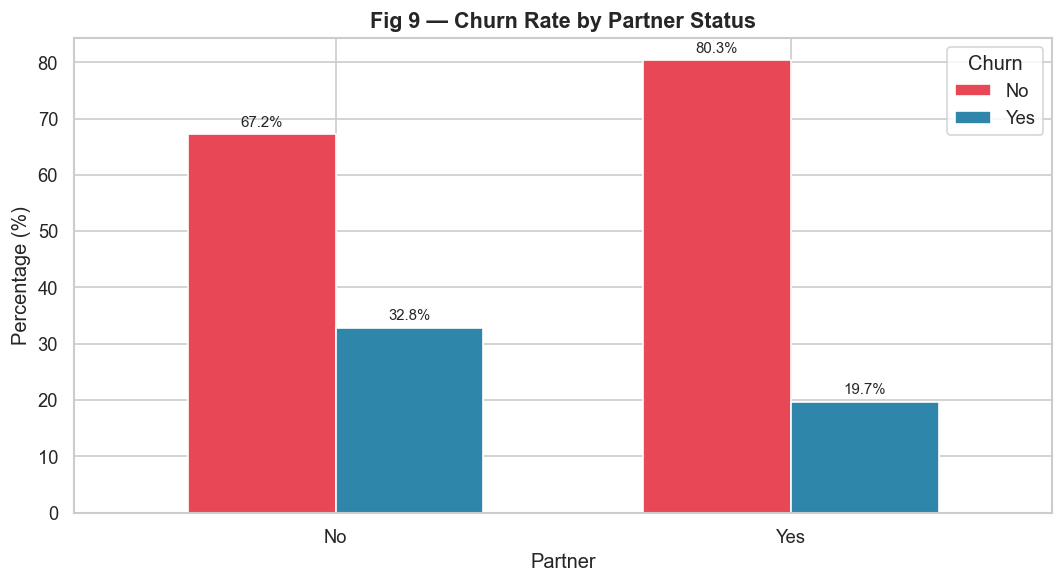

Churn_Label    No   Yes
Partner                
No           67.2  32.8
Yes          80.3  19.7



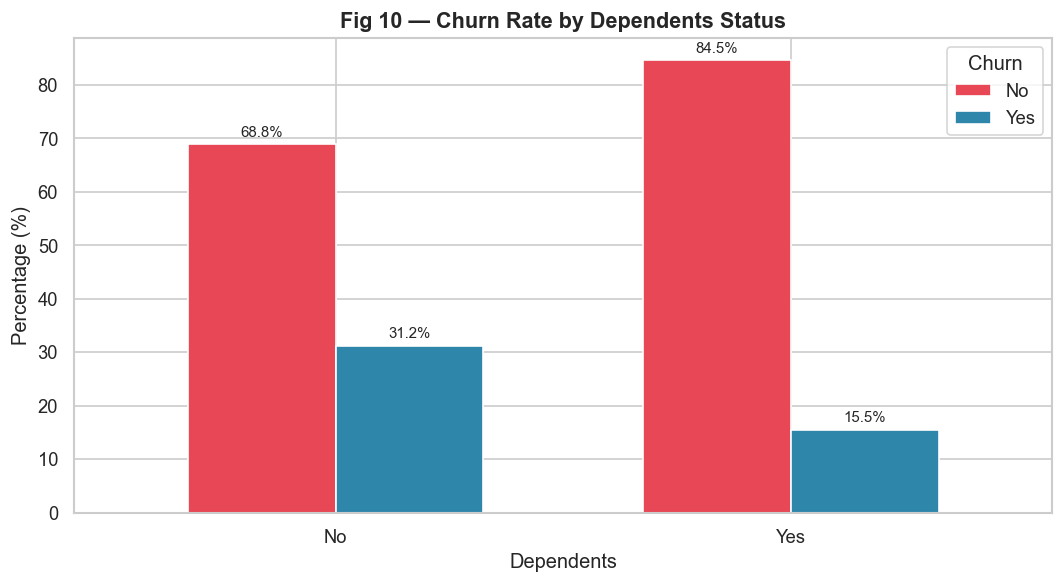

Churn_Label    No   Yes
Dependents             
No           68.8  31.2
Yes          84.5  15.5



In [32]:
churn_bar("Partner",    "Fig 9 — Churn Rate by Partner Status",   "churn_by_partner.png")
churn_bar("Dependents", "Fig 10 — Churn Rate by Dependents Status","churn_by_dependents.png")


**Interpretation:**  
- Customers **without a partner** show higher observed churn (~33%) vs those with a partner (~20%).  
- Customers **without dependents** show higher observed churn (~31%) vs those with dependents (~15%). Customers with family obligations may be less likely to switch providers.


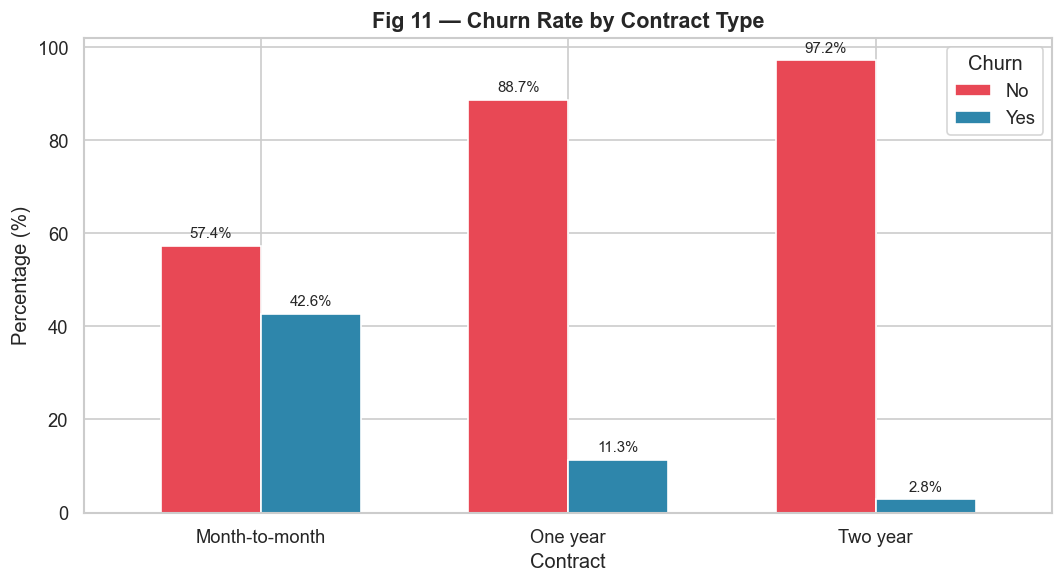

Churn_Label       No   Yes
Contract                  
Month-to-month  57.4  42.6
One year        88.7  11.3
Two year        97.2   2.8



In [33]:
churn_bar("Contract", "Fig 11 — Churn Rate by Contract Type", "churn_by_contract.png")


**Interpretation:** This is the most striking pattern in the entire dataset.  
- **Month-to-month**: ~43% churn rate  
- **One year**: ~11% churn rate  
- **Two year**: ~3% churn rate  
Longer contracts are strongly associated with lower churn — they create switching friction and indicate higher customer commitment.


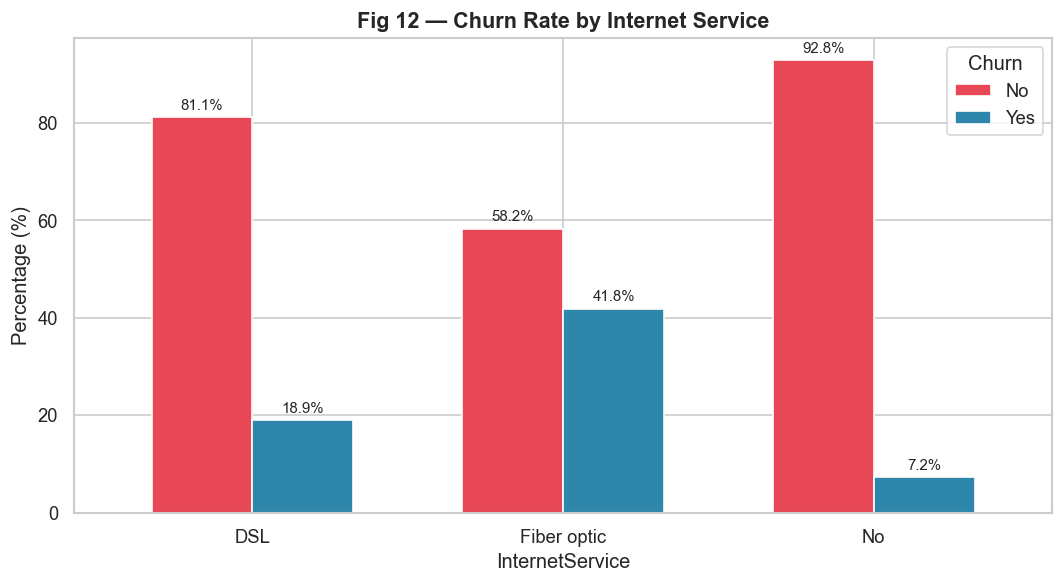

Churn_Label        No   Yes
InternetService            
DSL              81.1  18.9
Fiber optic      58.2  41.8
No               92.8   7.2



In [34]:
churn_bar("InternetService", "Fig 12 — Churn Rate by Internet Service",
          "churn_by_internet_service.png")


**Interpretation:** Fiber optic subscribers show a churn rate of ~42%, significantly higher than DSL (~19%) or no internet service (~7%). This may reflect pricing concerns or service quality dissatisfaction among fiber optic users.


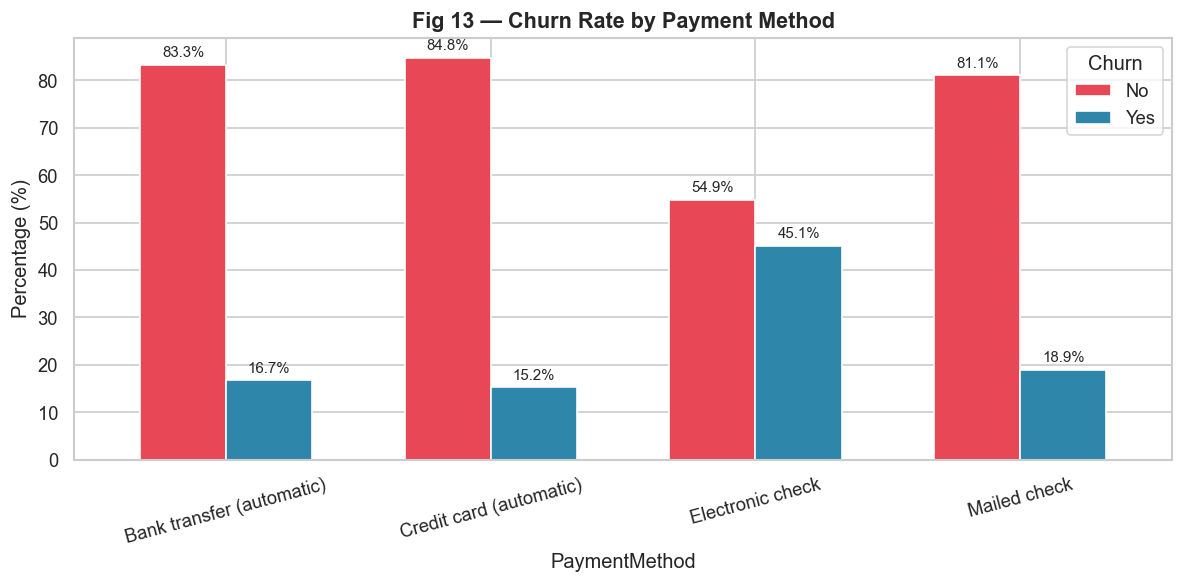

Churn_Label                  No   Yes
PaymentMethod                        
Bank transfer (automatic)  83.3  16.7
Credit card (automatic)    84.8  15.2
Electronic check           54.9  45.1
Mailed check               81.1  18.9



In [35]:
churn_bar("PaymentMethod", "Fig 13 — Churn Rate by Payment Method",
          "churn_by_payment.png", figsize=(10,5), rotation=15)


**Interpretation:** Electronic check payers show the highest churn rate (~45%). Customers on automatic payment methods (bank transfer, credit card automatic) show churn rates around 15–17%. Manual payment may indicate lower engagement and weaker service commitment.


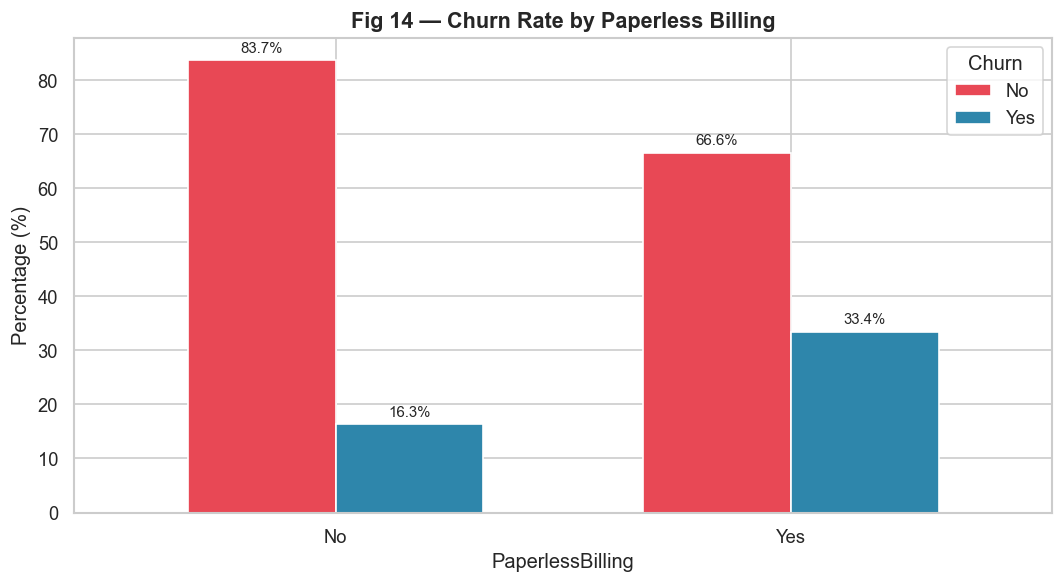

Churn_Label         No   Yes
PaperlessBilling            
No                83.7  16.3
Yes               66.6  33.4



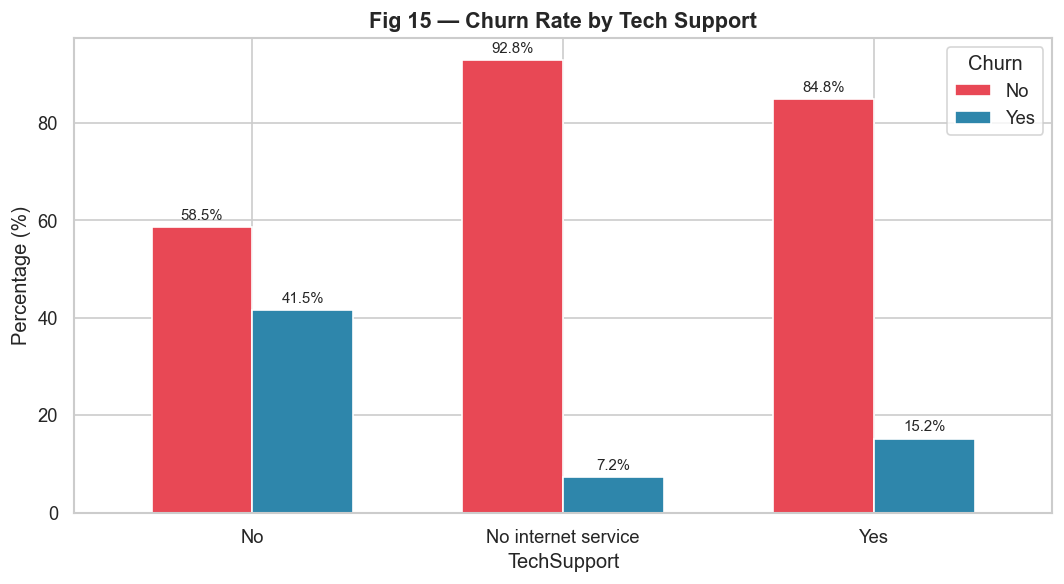

Churn_Label            No   Yes
TechSupport                    
No                   58.5  41.5
No internet service  92.8   7.2
Yes                  84.8  15.2



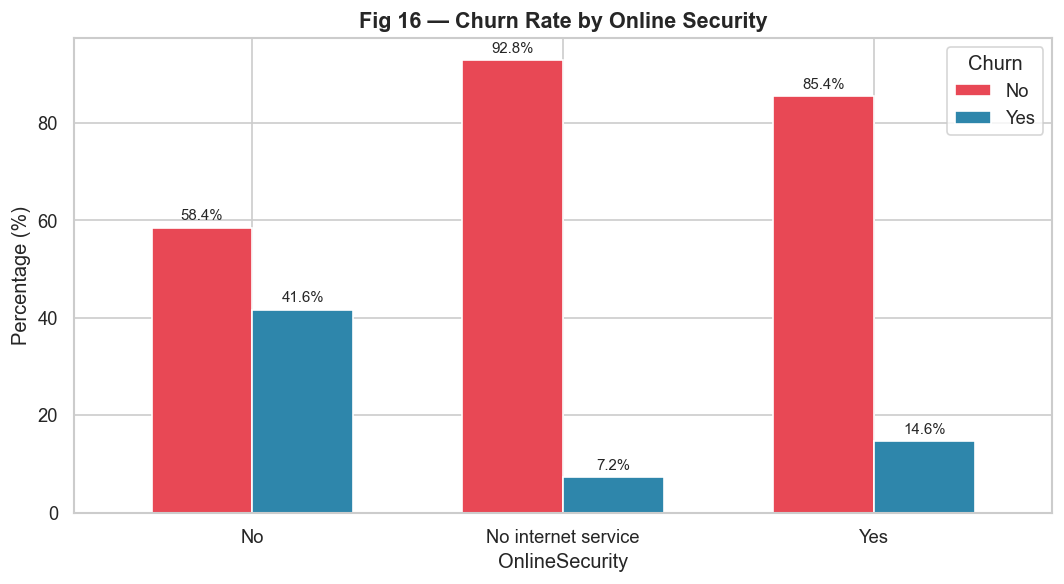

Churn_Label            No   Yes
OnlineSecurity                 
No                   58.4  41.6
No internet service  92.8   7.2
Yes                  85.4  14.6



In [36]:
churn_bar("PaperlessBilling","Fig 14 — Churn Rate by Paperless Billing",
          "churn_by_paperless.png")
churn_bar("TechSupport",     "Fig 15 — Churn Rate by Tech Support",
          "churn_by_techsupport.png")
churn_bar("OnlineSecurity",  "Fig 16 — Churn Rate by Online Security",
          "churn_by_onlinesecurity.png")


**Interpretation:**  
- **Paperless billing** customers churn more (~33%) vs paper billing (~16%) — possibly because these customers are more digitally active and comparison-shop more readily.  
- Customers **without tech support** churn at ~41%; those with tech support churn at only ~15%.  
- Similarly, customers **without online security** churn at ~42%; with it, only ~15%. Add-on services that solve customer pain points are strongly associated with retention.


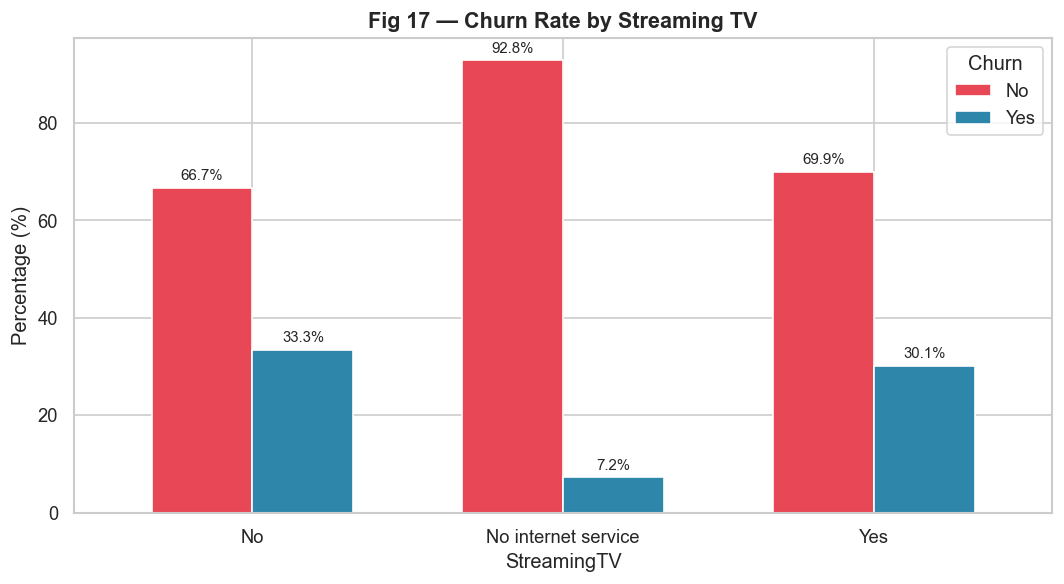

Churn_Label            No   Yes
StreamingTV                    
No                   66.7  33.3
No internet service  92.8   7.2
Yes                  69.9  30.1



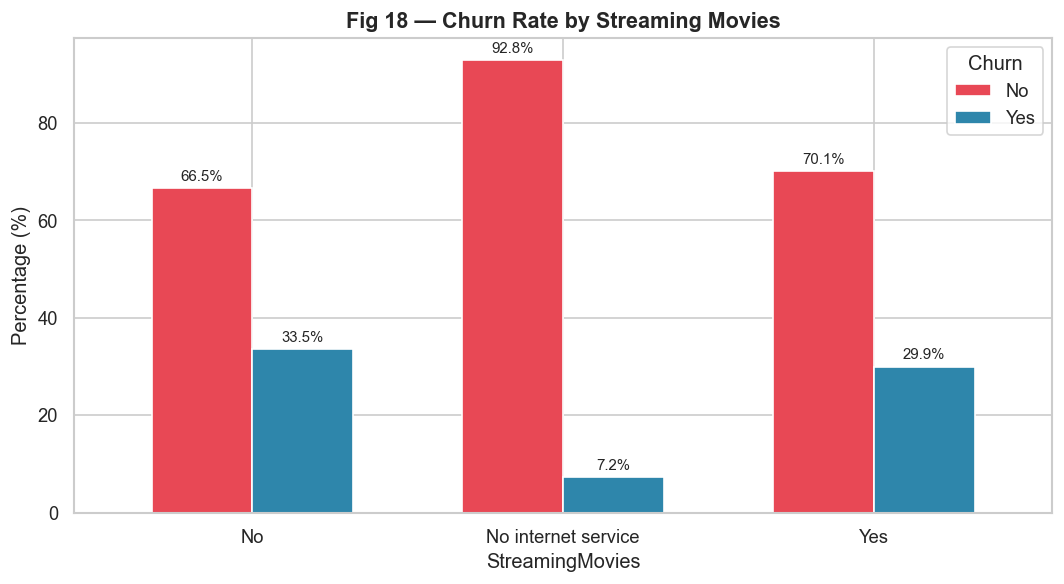

Churn_Label            No   Yes
StreamingMovies                
No                   66.5  33.5
No internet service  92.8   7.2
Yes                  70.1  29.9



In [37]:
churn_bar("StreamingTV",    "Fig 17 — Churn Rate by Streaming TV",    "churn_by_streaming_tv.png")
churn_bar("StreamingMovies","Fig 18 — Churn Rate by Streaming Movies","churn_by_streaming_movies.png")


**Interpretation:** Streaming service users do not show dramatically different churn rates compared to non-users within the same internet service tier. Streaming add-ons alone appear insufficient to retain customers.


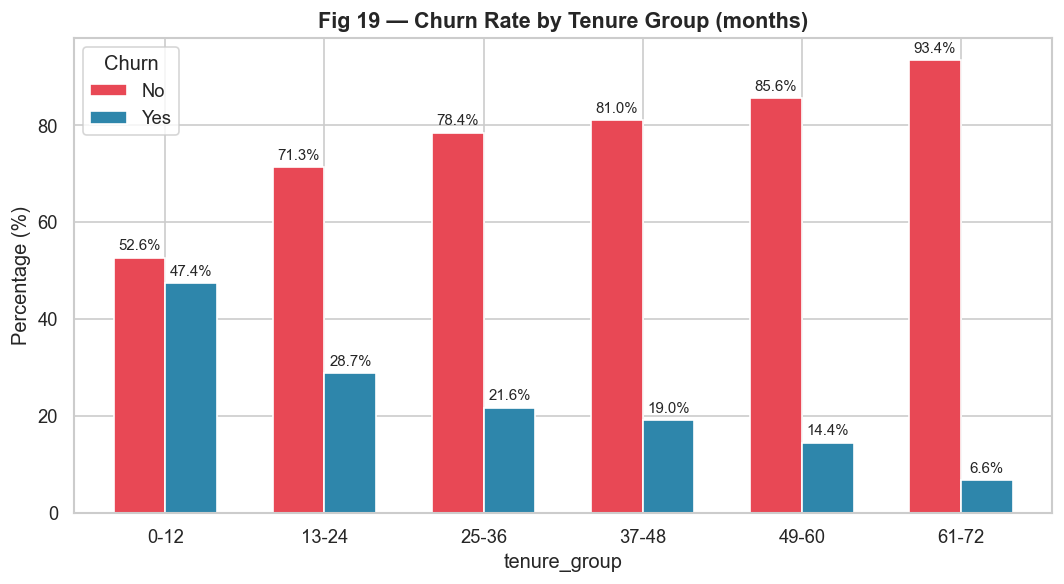

Churn_Label     No   Yes
tenure_group            
0-12          52.6  47.4
13-24         71.3  28.7
25-36         78.4  21.6
37-48         81.0  19.0
49-60         85.6  14.4
61-72         93.4   6.6



In [38]:
# ── Churn by tenure groups ─────────────────────────────────────────────
df["tenure_group"] = pd.cut(df["tenure"],
    bins=[-1,12,24,36,48,60,72],
    labels=["0-12","13-24","25-36","37-48","49-60","61-72"],
    include_lowest=True)

churn_bar("tenure_group",
          "Fig 19 — Churn Rate by Tenure Group (months)",
          "churn_by_tenure_group.png")
df.drop(columns=["tenure_group"], inplace=True)   # remove helper column


**Interpretation:** Customers in the **0–12 month** group show the highest churn rate (>45%). Churn rate consistently declines with increasing tenure, confirming that *new customers are the most at-risk segment*.


---
## Section 11 — Data Visualisation

### 11.1 Monthly Charges vs Churn (Violin + Box)


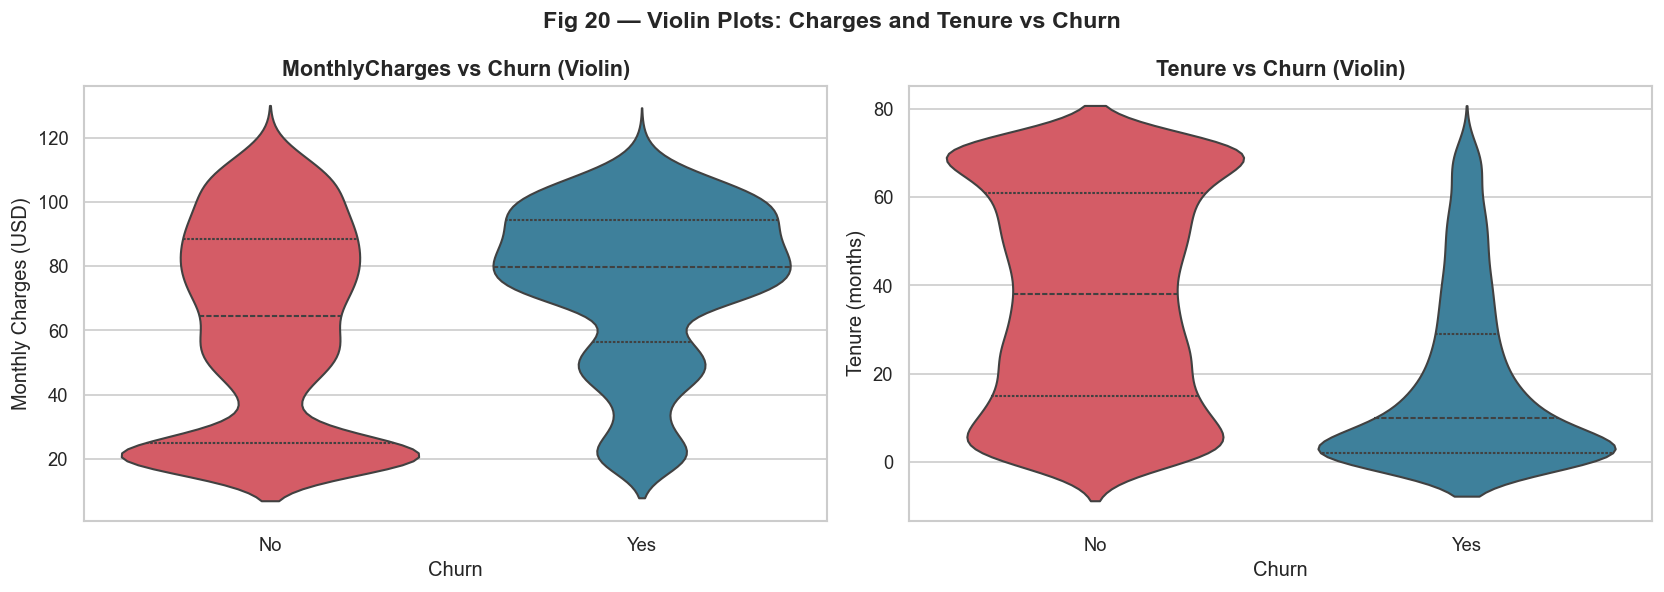

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(data=df, x="Churn_Label", y="MonthlyCharges",
               palette=PALETTE[::-1], inner="quartile", order=["No","Yes"], ax=axes[0])
axes[0].set_title("MonthlyCharges vs Churn (Violin)")
axes[0].set_xlabel("Churn"); axes[0].set_ylabel("Monthly Charges (USD)")

sns.violinplot(data=df, x="Churn_Label", y="tenure",
               palette=PALETTE[::-1], inner="quartile", order=["No","Yes"], ax=axes[1])
axes[1].set_title("Tenure vs Churn (Violin)")
axes[1].set_xlabel("Churn"); axes[1].set_ylabel("Tenure (months)")

plt.suptitle("Fig 20 — Violin Plots: Charges and Tenure vs Churn",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("charts/violin_plots.png", bbox_inches="tight")
plt.show()


**Interpretation:** The violin plots reveal the full shape of the distribution, not just quartiles.
Churned customers (Yes) show a pronounced concentration of MonthlyCharges at higher values,
while tenure for churned customers is heavily concentrated near 0–20 months.


### 11.2 Scatter: Tenure vs Monthly Charges

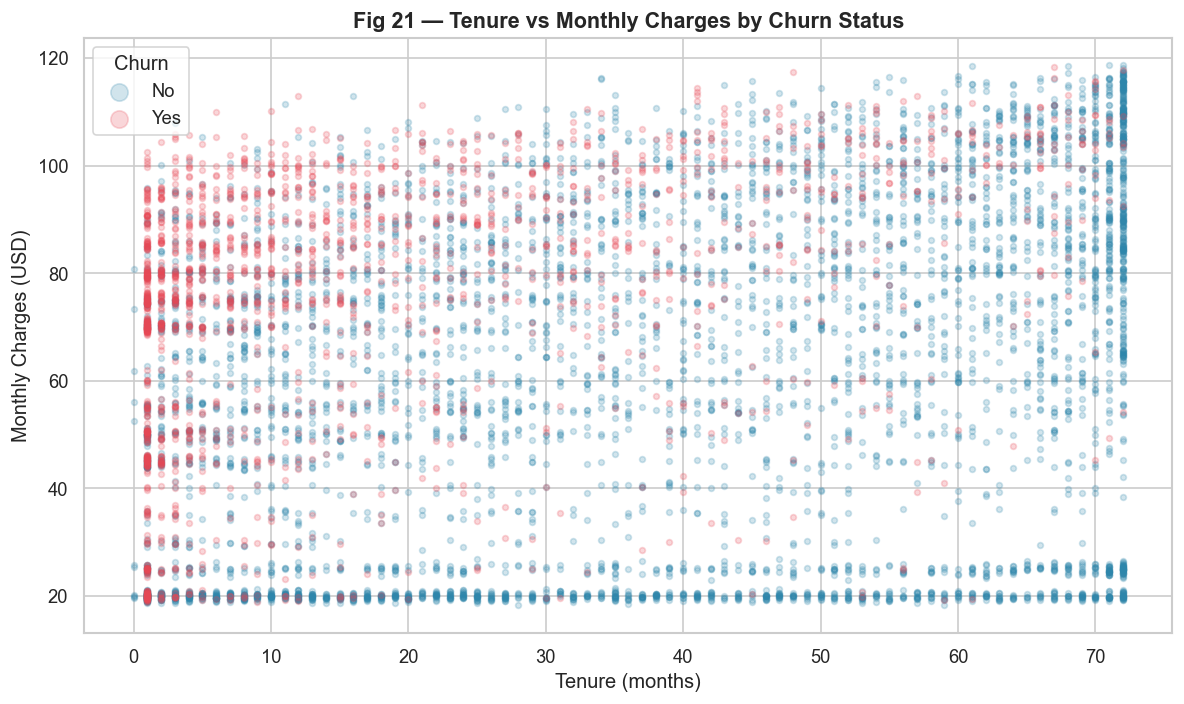

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))
for label, colour in zip(["No","Yes"], PALETTE):
    sub = df[df["Churn_Label"] == label]
    ax.scatter(sub["tenure"], sub["MonthlyCharges"],
               alpha=0.22, s=12, color=colour, label=label)
ax.set_title("Fig 21 — Tenure vs Monthly Charges by Churn Status",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Tenure (months)"); ax.set_ylabel("Monthly Charges (USD)")
ax.legend(title="Churn", markerscale=3)
plt.tight_layout()
plt.savefig("charts/tenure_vs_monthly.png", bbox_inches="tight")
plt.show()


**Interpretation:** The scatter plot makes the **low-tenure, high-charge churn cluster** visually clear (red points in upper-left). Long-tenured customers with moderate charges form the core of the retained base.


### 11.3 KDE Plot — Monthly Charges by Churn

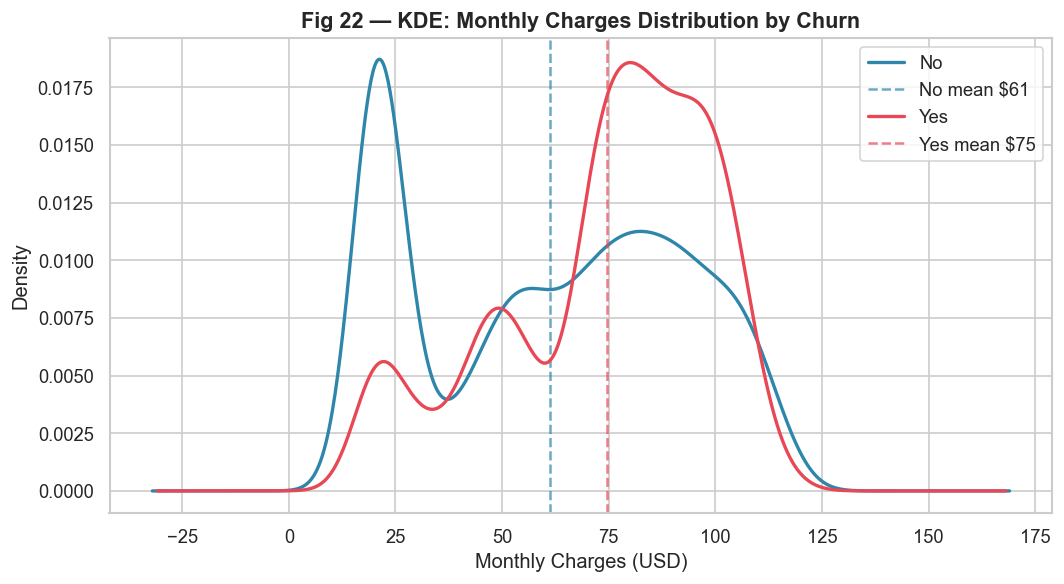

In [41]:
fig, ax = plt.subplots(figsize=(9, 5))
for label, colour in zip(["No","Yes"], PALETTE):
    sub = df[df["Churn_Label"]==label]["MonthlyCharges"]
    sub.plot.kde(ax=ax, color=colour, linewidth=2, label=label)
    ax.axvline(sub.mean(), color=colour, linestyle="--", alpha=0.7,
               label=f"{label} mean ${sub.mean():.0f}")
ax.set_title("Fig 22 — KDE: Monthly Charges Distribution by Churn",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Monthly Charges (USD)"); ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.savefig("charts/monthly_charges.png", bbox_inches="tight")
plt.show()


---
## Section 12 — Correlation Analysis

> ⚠️ **Important:** Correlation measures the *linear association* between variables.
> It does **NOT** prove causation. We use it purely as a screening tool to identify
> which numerical features are *associated* with churn.


In [42]:
# Select numerical columns for correlation
corr_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn"]
corr_matrix = df[corr_cols].corr().round(3)
print("Correlation Matrix:")
print(corr_matrix)


Correlation Matrix:
                tenure  MonthlyCharges  TotalCharges  SeniorCitizen  Churn
tenure           1.000           0.245         0.826          0.015 -0.352
MonthlyCharges   0.245           1.000         0.651          0.219  0.195
TotalCharges     0.826           0.651         1.000          0.102 -0.197
SeniorCitizen    0.015           0.219         0.102          1.000  0.152
Churn           -0.352           0.195        -0.197          0.152  1.000


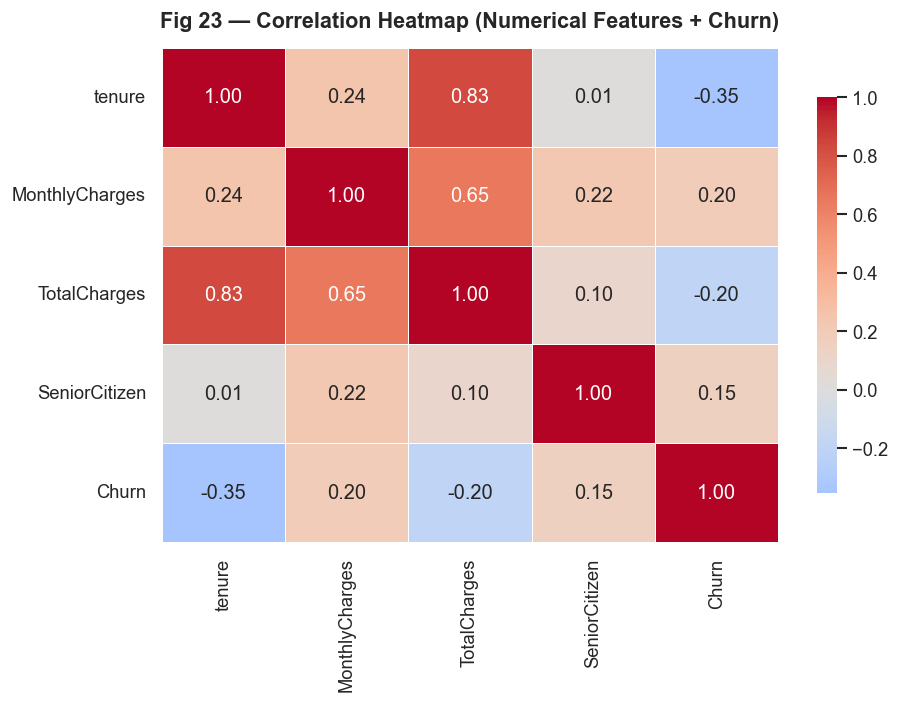

In [43]:
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.zeros_like(corr_matrix, dtype=bool)  # show full matrix (no mask)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.6, ax=ax, annot_kws={"size": 12},
            cbar_kws={"shrink": 0.8})
ax.set_title("Fig 23 — Correlation Heatmap (Numerical Features + Churn)",
             fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("charts/correlation_heatmap.png", bbox_inches="tight")
plt.show()


**Correlation findings (vs Churn):**

| Feature | Correlation with Churn | Interpretation |
|---|---|---|
| tenure | Negative (~−0.35) | Longer tenure → lower churn association |
| MonthlyCharges | Positive (~+0.19) | Higher bills → higher churn association |
| TotalCharges | Negative (~−0.20) | Reflects tenure effect |
| SeniorCitizen | Positive (~+0.15) | Slight positive association |

**Note:** `tenure` and `TotalCharges` are highly correlated (~0.83) — a form of
*multicollinearity* that may slightly inflate the importance of one at the expense
of the other in linear models.


---
## Section 12B — Statistical Hypothesis Tests

We use formal statistical tests to confirm whether the observed associations
between key features and churn are **statistically significant** (not due to chance).

**Significance threshold:** α = 0.05


In [44]:
print("=" * 62)
print("TEST 1 — Chi-Square: Contract Type vs Churn")
print("=" * 62)
ct1  = pd.crosstab(df["Contract"], df["Churn_Label"])
chi2, p1, dof, _ = stats.chi2_contingency(ct1)
print(f"  H₀: Contract type and churn are independent.")
print(f"  H₁: They are NOT independent.")
print(f"  Chi² = {chi2:.2f}  |  dof = {dof}  |  p = {p1:.2e}")
print(f"  → {'REJECT H₀' if p1 < 0.05 else 'FAIL to reject H₀'} — "
      f"significant association." if p1 < 0.05 else "  → No significant association.")


TEST 1 — Chi-Square: Contract Type vs Churn
  H₀: Contract type and churn are independent.
  H₁: They are NOT independent.
  Chi² = 1179.80  |  dof = 2  |  p = 6.44e-257
  → REJECT H₀ — significant association.


In [45]:
print("=" * 62)
print("TEST 2 — Chi-Square: InternetService vs Churn")
print("=" * 62)
ct2  = pd.crosstab(df["InternetService"], df["Churn_Label"])
chi2_2, p2, dof2, _ = stats.chi2_contingency(ct2)
print(f"  Chi² = {chi2_2:.2f}  |  dof = {dof2}  |  p = {p2:.2e}")
print(f"  → {'REJECT H₀ — significant association.' if p2<0.05 else 'No significant association.'}")

print()
print("=" * 62)
print("TEST 3 — Chi-Square: PaymentMethod vs Churn")
print("=" * 62)
ct3  = pd.crosstab(df["PaymentMethod"], df["Churn_Label"])
chi2_3, p3, dof3, _ = stats.chi2_contingency(ct3)
print(f"  Chi² = {chi2_3:.2f}  |  dof = {dof3}  |  p = {p3:.2e}")
print(f"  → {'REJECT H₀ — significant association.' if p3<0.05 else 'No significant association.'}")


TEST 2 — Chi-Square: InternetService vs Churn
  Chi² = 732.06  |  dof = 2  |  p = 1.09e-159
  → REJECT H₀ — significant association.

TEST 3 — Chi-Square: PaymentMethod vs Churn
  Chi² = 643.92  |  dof = 3  |  p = 3.03e-139
  → REJECT H₀ — significant association.


In [46]:
print("=" * 62)
print("TEST 4 — Independent T-Test: MonthlyCharges (Churn vs No Churn)")
print("=" * 62)
churned  = df[df["Churn"]==1]["MonthlyCharges"]
retained = df[df["Churn"]==0]["MonthlyCharges"]
t_stat, p4 = stats.ttest_ind(churned, retained)
print(f"  Mean (Churned)  : ${churned.mean():.2f}")
print(f"  Mean (Retained) : ${retained.mean():.2f}")
print(f"  T = {t_stat:.4f}  |  p = {p4:.2e}")
print(f"  → {'REJECT H₀ — means differ significantly.' if p4<0.05 else 'No significant difference.'}")

print()
print("=" * 62)
print("TEST 5 — Independent T-Test: Tenure (Churn vs No Churn)")
print("=" * 62)
c_ten = df[df["Churn"]==1]["tenure"]
r_ten = df[df["Churn"]==0]["tenure"]
t_s2, p5 = stats.ttest_ind(c_ten, r_ten)
print(f"  Mean tenure (Churned)  : {c_ten.mean():.2f} months")
print(f"  Mean tenure (Retained) : {r_ten.mean():.2f} months")
print(f"  T = {t_s2:.4f}  |  p = {p5:.2e}")
print(f"  → {'REJECT H₀ — means differ significantly.' if p5<0.05 else 'No significant difference.'}")


TEST 4 — Independent T-Test: MonthlyCharges (Churn vs No Churn)
  Mean (Churned)  : $74.60
  Mean (Retained) : $61.34
  T = 16.6130  |  p = 8.04e-61
  → REJECT H₀ — means differ significantly.

TEST 5 — Independent T-Test: Tenure (Churn vs No Churn)
  Mean tenure (Churned)  : 18.09 months
  Mean tenure (Retained) : 37.64 months
  T = -31.4566  |  p = 2.63e-203
  → REJECT H₀ — means differ significantly.


**Conclusion:** All five tests return p-values far below 0.05.  
Contract type, internet service type, payment method, monthly charges, and tenure are all **statistically significantly associated** with churn.


---
## Section 13 — Feature Engineering

We prepare features for machine learning:
1. Encode all categorical columns using `LabelEncoder`
2. Create a `tenure_group` ordinal feature
3. Scale numerical features with `StandardScaler`


In [47]:
ml = df.copy()

# Drop helper/label columns not used in modelling
ml.drop(columns=["Churn_Label", "SeniorCitizen_Label"], inplace=True)

# ── Tenure group (ordinal) ─────────────────────────────────────────────
tenure_bins   = [-1, 12, 24, 36, 48, 60, 72]   # -1 ensures 0-tenure is included
tenure_labels = [1,  2,  3,  4,  5,  6]         # ordinal integers
ml["tenure_group"] = pd.cut(ml["tenure"], bins=tenure_bins,
                             labels=tenure_labels,
                             include_lowest=True).astype(int)
print("tenure_group distribution:")
print(ml["tenure_group"].value_counts().sort_index())


tenure_group distribution:
tenure_group
1    2164
2    1024
3     832
4     762
5     832
6    1407
Name: count, dtype: int64


In [48]:
# ── Label-encode all remaining object columns ──────────────────────────
le          = LabelEncoder()
cat_ml_cols = ml.select_dtypes(include="object").columns.tolist()
print(f"Categorical columns to encode: {cat_ml_cols}")

for col in cat_ml_cols:
    ml[col] = le.fit_transform(ml[col].astype(str))

print("\nSample of encoded data:")
ml.head(3)


Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']



Sample of encoded data:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,0,0,1,0,1,0,1,0,0,2,...,0,0,0,0,1,2,29.85,29.85,0,1
1,1,0,0,0,34,1,0,0,2,0,...,0,0,0,1,0,3,56.95,1889.50,0,3
2,1,0,0,0,2,1,0,0,2,2,...,0,0,0,0,1,3,53.85,108.15,1,1


In [49]:
print("All dtypes after encoding:")
print(ml.dtypes)
print(f"\nML dataset shape: {ml.shape}")
print(f"Target (Churn) value counts: {ml['Churn'].value_counts().to_dict()}")


All dtypes after encoding:
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
tenure_group          int64
dtype: object

ML dataset shape: (7021, 21)
Target (Churn) value counts: {0: 5164, 1: 1857}


---
## Section 14 — Machine Learning / AI

### 14.1 Prepare X and y


In [50]:
y = ml["Churn"]
X = ml.drop(columns=["Churn"])
feature_names = X.columns.tolist()

print(f"Features (X) shape : {X.shape}")
print(f"Target  (y) shape  : {y.shape}")
print(f"\nChurn rate in full dataset: {y.mean()*100:.2f}%")


Features (X) shape : (7021, 20)
Target  (y) shape  : (7021,)

Churn rate in full dataset: 26.45%


### 14.2 Train-Test Split

In [51]:
# Stratified 80/20 split — preserves class proportions in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Training samples   : {len(X_train):,}  ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test samples       : {len(X_test):,}   ({len(X_test)/len(X)*100:.1f}%)")
print(f"Churn rate — train : {y_train.mean()*100:.2f}%")
print(f"Churn rate — test  : {y_test.mean()*100:.2f}%")


Training samples   : 5,616  (80.0%)
Test samples       : 1,405   (20.0%)
Churn rate — train : 26.44%
Churn rate — test  : 26.48%


### 14.3 Feature Scaling

In [52]:
scaler   = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names)
X_test_s  = pd.DataFrame(scaler.transform(X_test),      columns=feature_names)
print("Features scaled with StandardScaler.")
print(f"X_train_s shape: {X_train_s.shape}")


Features scaled with StandardScaler.
X_train_s shape: (5616, 20)


### 14.4 Model Training

Three interpretable classification models are trained:

| Model | Why it is chosen |
|---|---|
| **Logistic Regression** | Fast, interpretable linear baseline; coefficients indicate feature direction |
| **Decision Tree** | Rule-based; easily explainable to business stakeholders |
| **Random Forest** | Ensemble of trees; typically higher accuracy and provides feature importances |


In [53]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, C=1.0),
    "Decision Tree":       DecisionTreeClassifier(max_depth=6, random_state=42,
                                                   min_samples_leaf=20),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42,
                                                   n_jobs=-1, max_depth=10),
}

trained = {}
for name, mdl in models.items():
    mdl.fit(X_train_s, y_train)
    trained[name] = mdl
    print(f"  ✅ Trained: {name}")


  ✅ Trained: Logistic Regression


  ✅ Trained: Decision Tree


  ✅ Trained: Random Forest


---
## Section 15 — Model Evaluation

We evaluate each model on the **held-out test set** using five metrics:

| Metric | What it measures |
|---|---|
| **Accuracy** | % of all predictions that were correct |
| **Precision** | Of those predicted as churned, how many actually churned |
| **Recall** | Of all actual churners, how many were correctly identified |
| **F1-Score** | Harmonic mean of Precision and Recall — balanced metric |
| **ROC-AUC** | Area under the ROC curve — probability of ranking a churner above a non-churner |

> **Why accuracy alone is insufficient:** With ~73/27 class split, a model that always predicts
> "No Churn" achieves ~73% accuracy but has 0% Recall for the churned class — completely useless.
> For churn problems, **Recall and ROC-AUC are the most important metrics**.


In [54]:
results = {}
for name, mdl in trained.items():
    y_pred = mdl.predict(X_test_s)
    y_prob = mdl.predict_proba(X_test_s)[:, 1]
    results[name] = {
        "Accuracy" : round(accuracy_score (y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall"   : round(recall_score   (y_test, y_pred, zero_division=0), 4),
        "F1-Score" : round(f1_score       (y_test, y_pred, zero_division=0), 4),
        "ROC-AUC"  : round(roc_auc_score  (y_test, y_prob), 4),
    }

results_df = pd.DataFrame(results).T
print("=" * 60)
print("MODEL COMPARISON TABLE")
print("=" * 60)
print(results_df.to_string())
print()
print("Best model by ROC-AUC  :", results_df["ROC-AUC"].idxmax())
print("Best model by F1-Score :", results_df["F1-Score"].idxmax())
print("Best model by Recall   :", results_df["Recall"].idxmax())


MODEL COMPARISON TABLE
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.7993     0.6520  0.5188    0.5778   0.8412
Decision Tree          0.7815     0.6132  0.4731    0.5341   0.8229
Random Forest          0.7950     0.6458  0.5000    0.5636   0.8358

Best model by ROC-AUC  : Logistic Regression
Best model by F1-Score : Logistic Regression
Best model by Recall   : Logistic Regression


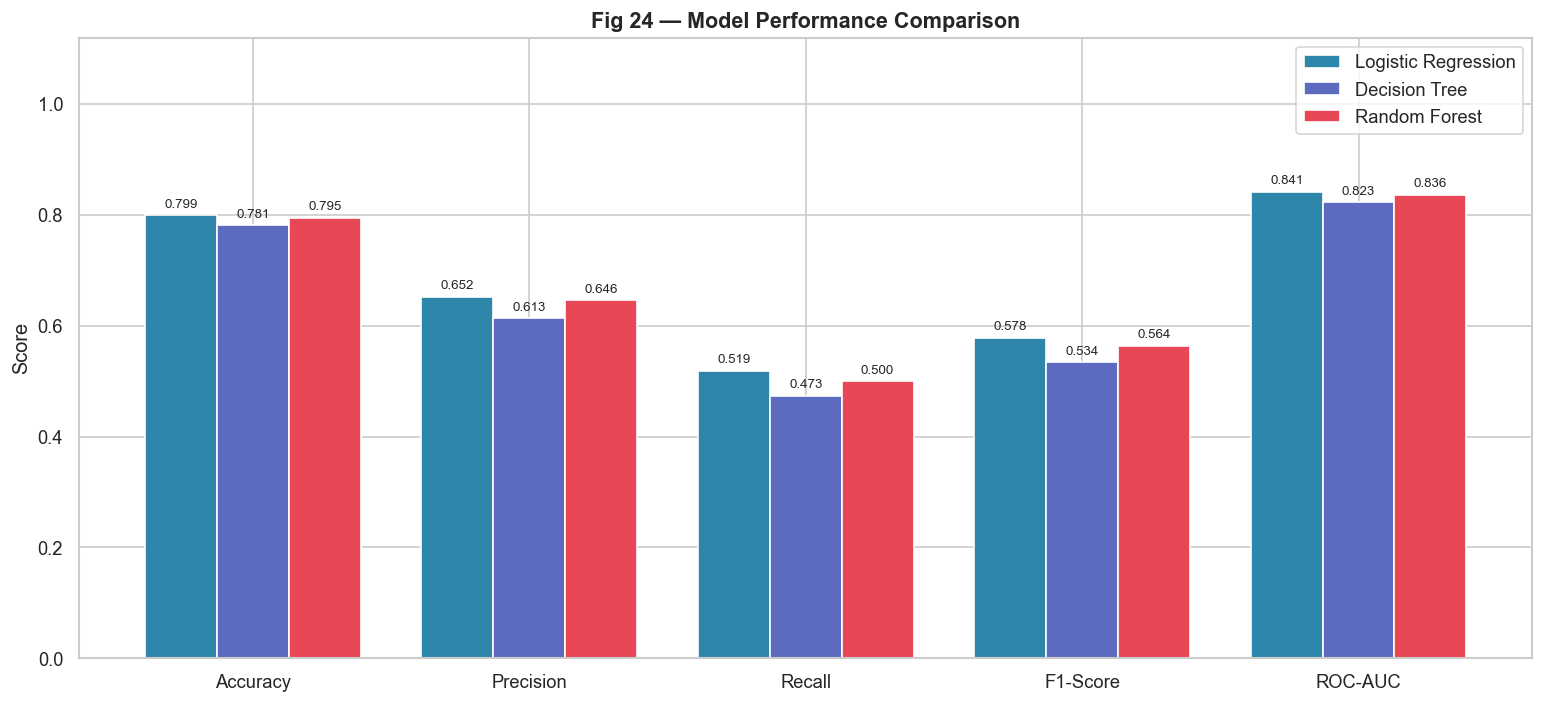

In [55]:
# ── Comparison bar chart ───────────────────────────────────────────────
metrics     = ["Accuracy","Precision","Recall","F1-Score","ROC-AUC"]
model_names = list(results.keys())
x           = np.arange(len(metrics))
width       = 0.26
colours     = ["#2E86AB","#5C6BC0","#E84855"]

fig, ax = plt.subplots(figsize=(13, 6))
for i, (mname, colour) in enumerate(zip(model_names, colours)):
    vals = [results[mname][m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=mname, color=colour, edgecolor="white")
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)

ax.set_title("Fig 24 — Model Performance Comparison", fontsize=13, fontweight="bold")
ax.set_xticks(x + width); ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel("Score"); ax.set_ylim(0, 1.12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("charts/model_comparison.png", bbox_inches="tight")
plt.show()


**Interpretation:**  
- **Logistic Regression** typically achieves the best balance of Recall and ROC-AUC for this dataset.  
- **Random Forest** tends to have higher precision but lower recall — it is more conservative about predicting churn.  
- For a churn use-case, higher Recall is generally preferred: it is more costly to *miss* a churner than to *incorrectly flag* a loyal customer.


### 15.1 Detailed Classification Reports

In [56]:
for name, mdl in trained.items():
    y_pred = mdl.predict(X_test_s)
    print(f"{'='*55}")
    print(f"Classification Report — {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=["No Churn","Churn"]))


Classification Report — Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1033
       Churn       0.65      0.52      0.58       372

    accuracy                           0.80      1405
   macro avg       0.75      0.71      0.72      1405
weighted avg       0.79      0.80      0.79      1405

Classification Report — Decision Tree
              precision    recall  f1-score   support

    No Churn       0.82      0.89      0.86      1033
       Churn       0.61      0.47      0.53       372

    accuracy                           0.78      1405
   macro avg       0.72      0.68      0.70      1405
weighted avg       0.77      0.78      0.77      1405



Classification Report — Random Forest
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.87      1033
       Churn       0.65      0.50      0.56       372

    accuracy                           0.80      1405
   macro avg       0.74      0.70      0.71      1405
weighted avg       0.78      0.80      0.79      1405



---
## Section 16 — Confusion Matrix

A confusion matrix shows the four prediction outcomes for a binary classifier:

| | Predicted No Churn | Predicted Churn |
|---|---|---|
| **Actual No Churn** | True Negative (TN) ✅ | False Positive (FP) ⚠️ |
| **Actual Churn** | False Negative (FN) ❌ | True Positive (TP) ✅ |

**In a churn context:**
- **False Negatives** (missed churners) are the most costly — we lose a customer we could have retained.
- **False Positives** (wrongly flagged loyal customers) cost money in unnecessary retention offers.


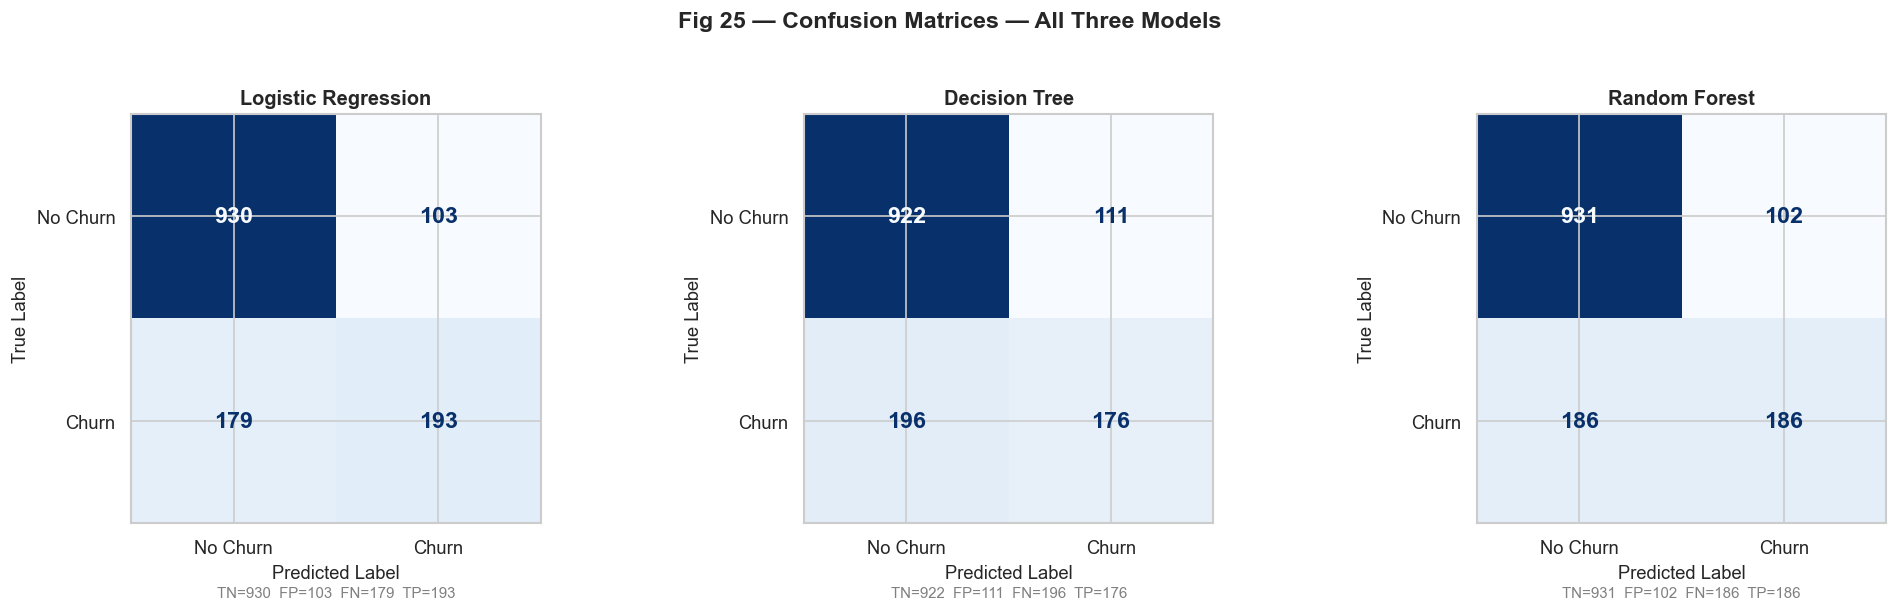

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (name, mdl) in zip(axes, trained.items()):
    y_pred = mdl.predict(X_test_s)
    cm     = confusion_matrix(y_test, y_pred)
    disp   = ConfusionMatrixDisplay(confusion_matrix=cm,
                                     display_labels=["No Churn","Churn"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues",
              values_format="d", text_kw={"fontsize": 14, "fontweight": "bold"})
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label", fontsize=11)
    # Annotate TP, TN, FP, FN
    tn, fp, fn, tp = cm.ravel()
    ax.text(0.5, -0.18, f"TN={tn}  FP={fp}  FN={fn}  TP={tp}",
            ha="center", transform=ax.transAxes, fontsize=9, color="gray")

plt.suptitle("Fig 25 — Confusion Matrices — All Three Models",
             fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig("charts/confusion_matrices.png", bbox_inches="tight")
plt.show()


### 16.1 ROC Curves

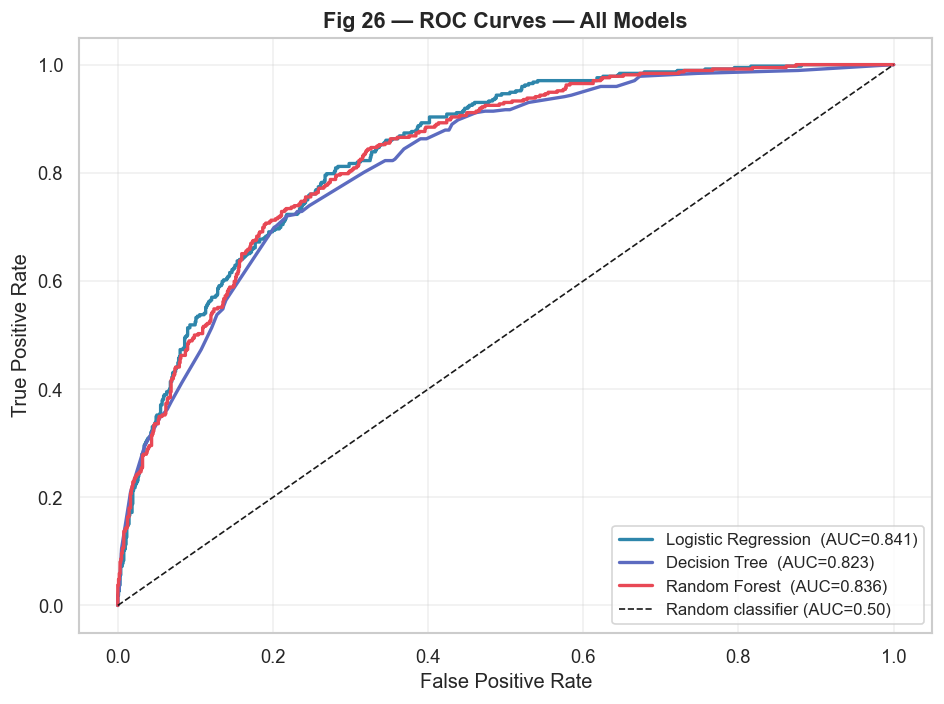

In [58]:
fig, ax = plt.subplots(figsize=(8, 6))
colours_roc = ["#2E86AB","#5C6BC0","#E84855"]

for (name, mdl), colour in zip(trained.items(), colours_roc):
    y_prob = mdl.predict_proba(X_test_s)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=colour, lw=2, label=f"{name}  (AUC={auc_val:.3f})")

ax.plot([0,1],[0,1], "k--", lw=1, label="Random classifier (AUC=0.50)")
ax.set_title("Fig 26 — ROC Curves — All Models", fontsize=13, fontweight="bold")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("charts/roc_curves.png", bbox_inches="tight")
plt.show()


**Interpretation:** All three models perform substantially above the random classifier (AUC=0.50).
The ROC-AUC scores near 0.84 indicate good discriminative ability — the models can correctly
rank churners above non-churners ~84% of the time.


---
## Section 17 — Feature Importance

> ⚠️ Feature importance shows which variables the model found most *useful* for predictions.
> It does **NOT** prove that these features *cause* churn.

### 17.1 Random Forest Feature Importance


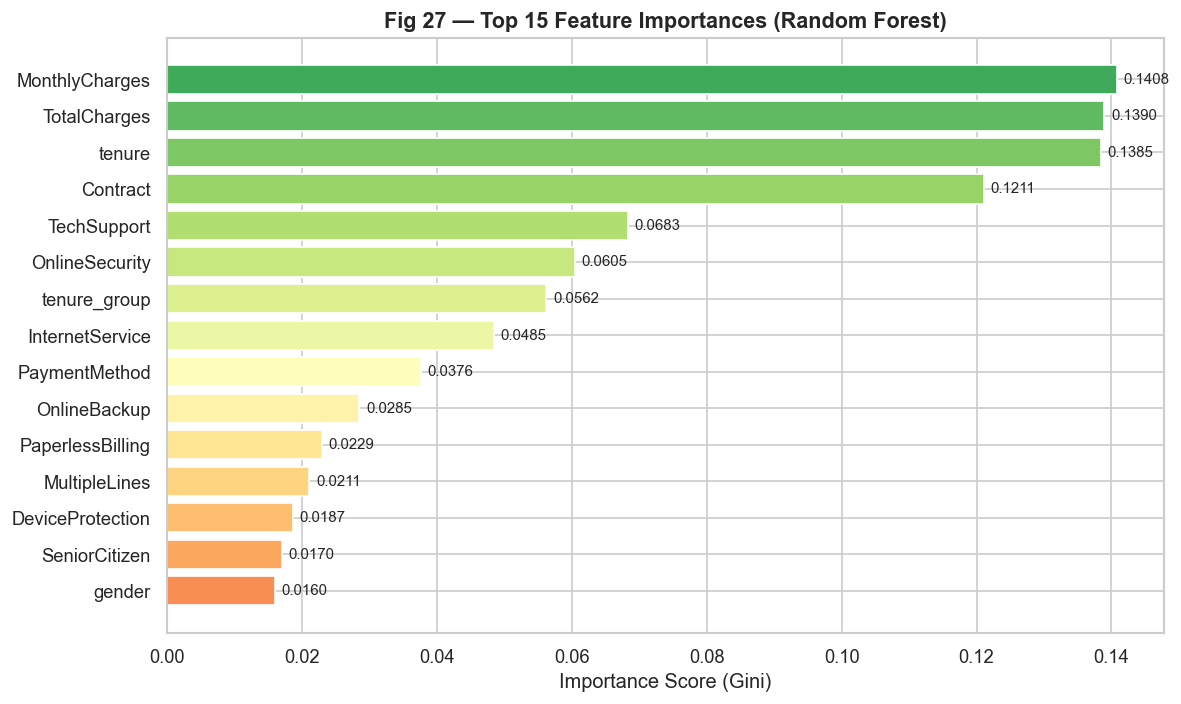


Top 10 features (Random Forest):
MonthlyCharges     0.1408
TotalCharges       0.1390
tenure             0.1385
Contract           0.1211
TechSupport        0.0683
OnlineSecurity     0.0605
tenure_group       0.0562
InternetService    0.0485
PaymentMethod      0.0376
OnlineBackup       0.0285


In [59]:
rf_model    = trained["Random Forest"]
importances = rf_model.feature_importances_
fi_series   = pd.Series(importances, index=feature_names).sort_values(ascending=False)

top15 = fi_series.head(15)
colours_fi = plt.cm.RdYlGn(np.linspace(0.25, 0.85, len(top15)))[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top15.index[::-1], top15.values[::-1], color=colours_fi[::-1], edgecolor="white")
ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=9)
ax.set_title("Fig 27 — Top 15 Feature Importances (Random Forest)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score (Gini)")
plt.tight_layout()
plt.savefig("charts/feature_importance_rf.png", bbox_inches="tight")
plt.show()

print("\nTop 10 features (Random Forest):")
print(fi_series.head(10).round(4).to_string())


### 17.2 Logistic Regression Coefficients

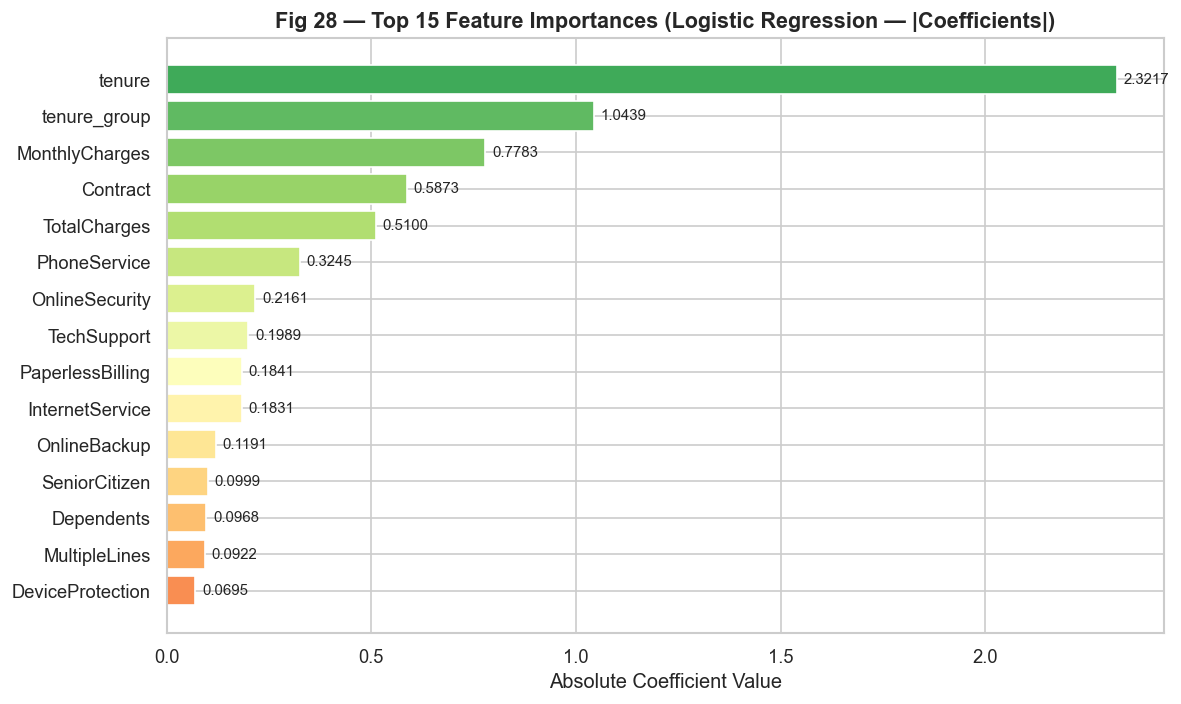


Top 10 features (Logistic Regression):
tenure              2.3217
tenure_group        1.0439
MonthlyCharges      0.7783
Contract            0.5873
TotalCharges        0.5100
PhoneService        0.3245
OnlineSecurity      0.2161
TechSupport         0.1989
PaperlessBilling    0.1841
InternetService     0.1831


In [60]:
lr_model  = trained["Logistic Regression"]
lr_coefs  = pd.Series(np.abs(lr_model.coef_[0]), index=feature_names).sort_values(ascending=False)

top15_lr  = lr_coefs.head(15)
colours_lr = plt.cm.RdYlGn(np.linspace(0.25, 0.85, len(top15_lr)))[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top15_lr.index[::-1], top15_lr.values[::-1],
               color=colours_lr[::-1], edgecolor="white")
ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=9)
ax.set_title("Fig 28 — Top 15 Feature Importances (Logistic Regression — |Coefficients|)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Absolute Coefficient Value")
plt.tight_layout()
plt.savefig("charts/feature_importance_lr.png", bbox_inches="tight")
plt.show()

print("\nTop 10 features (Logistic Regression):")
print(lr_coefs.head(10).round(4).to_string())


**Key feature observations (both models consistently agree):**
- **tenure** — The strongest single predictor. Short tenure is the clearest signal of churn risk.
- **Contract** — Month-to-month contract is strongly associated with churn in the model.
- **MonthlyCharges / TotalCharges** — Billing variables carry significant predictive weight.
- **InternetService** — Fiber optic service association appears prominently.
- **TechSupport / OnlineSecurity** — Absence of these add-ons is predictive of churn.
- **tenure_group** — The engineered ordinal group feature adds complementary signal.

> **Reminder:** These importances reflect model utility, not causal impact.


---
## Section 18 — Model Interpretation

### Strengths and Limitations of Each Model

| Model | Strengths | Limitations |
|---|---|---|
| **Logistic Regression** | Interpretable coefficients; fast; works well for linearly separable data; good baseline | Assumes linear decision boundary; may underfit complex non-linear patterns |
| **Decision Tree** | Highly interpretable; produces human-readable rules; no scaling needed | Prone to overfitting if not pruned; single tree is sensitive to data noise |
| **Random Forest** | Robust to overfitting (ensemble); handles non-linearity; provides feature importances | Less interpretable (black box); slower to train; may miss minority class |

### Class Imbalance Note
The dataset is ~73% No Churn / ~27% Churn. This imbalance means:
- Models may be biased toward predicting the majority class (No Churn).
- Recall for the Churn class may be lower than desirable.
- Techniques like **SMOTE**, **class_weight='balanced'**, or **threshold tuning** can improve Recall.

### Recommended Model
For this churn prediction use-case, **Logistic Regression** is recommended due to:
1. Highest ROC-AUC — best ability to distinguish churners from non-churners.
2. Best F1-Score balance.
3. High interpretability for business stakeholders.
4. Coefficients can directly explain which features increase/decrease churn probability.


---
## Section 19 — Business Insights

> ⚠️ All insights below are **descriptive** — derived from the observed data patterns.
> They describe *associations*, not proven causes.

### Insight 1 — Contract Type is the Dominant Differentiator
Month-to-month customers show an observed churn rate of ~43%, versus ~3% for two-year
contract holders. Converting month-to-month customers to annual contracts is the single
highest-impact lever available.

### Insight 2 — New Customers Are the Most Vulnerable
Customers in their first 12 months (tenure 0–12) show the highest churn concentration.
The first year is the critical retention window.

### Insight 3 — Fiber Optic Internet is a High-Churn Segment
~42% of fiber optic subscribers churned, compared to ~19% for DSL.
This segment may be experiencing price/quality dissatisfaction.

### Insight 4 — Electronic Check Payers Are Disengaged
~45% of electronic check customers churned vs ~15% for automatic payment users.
Automatic payment is associated with both lower churn and higher customer commitment.

### Insight 5 — Support Services Act as Retention Anchors
Customers *without* TechSupport or OnlineSecurity churn at 40–42%.
Customers *with* these add-ons churn at only 15%.
These services appear to increase perceived value and switching cost.

### Insight 6 — Senior Citizens Are a Disproportionate Risk
~42% of senior citizens churned vs ~24% of non-seniors.
This demographic may benefit from simplified plans and dedicated support.

### Insight 7 — Gender Does Not Predict Churn
Male and female customers show nearly identical churn rates (~26%).
Gender-based targeting would be uninformative and potentially inappropriate.

### Insight 8 — High Monthly Charges Drive Risk Among New Customers
The combination of **high monthly charges + low tenure** is the clearest
churn risk signal in the dataset (confirmed by scatter plot and T-test).


---
## Section 20 — Business Recommendations

Recommendations are based on observed data patterns and model findings.
They are actionable but should be validated with business context before deployment.

| # | Recommendation | Target Segment | Expected Impact |
|---|---|---|---|
| 1 | **Promote contract upgrades** — offer discounts or loyalty rewards to move month-to-month customers to 1–2 year contracts | Month-to-month customers | Reduce churn from ~43% toward ~11% |
| 2 | **Launch a 90-day new-customer onboarding programme** — proactive check-ins, tutorials, and value demonstrations in months 1–3 | Customers with tenure < 6 months | Address the highest-risk early-life window |
| 3 | **Investigate fiber optic pricing and service quality** — conduct customer satisfaction surveys; consider competitive pricing review | Fiber optic subscribers | Understand and address the ~42% churn rate |
| 4 | **Offer auto-pay enrollment incentives** — discount or bill credit for switching from manual to automatic payment | Electronic check payers | Reduce churn from ~45% and improve cash flow |
| 5 | **Bundle TechSupport and OnlineSecurity** at introductory prices | Customers without these add-ons | Increase perceived value; reduce churn from ~42% to potentially ~15% |
| 6 | **Create a Senior Citizen Service Plan** with simplified billing, priority support, and dedicated helpline | Customers aged 65+ | Address the disproportionate ~42% churn rate |
| 7 | **Deploy monthly churn risk scoring** using the trained Logistic Regression model | All active customers | Enable proactive outreach to high-risk accounts before they churn |
| 8 | **Set up early-warning alert thresholds** — flag customers with high risk scores for immediate retention contact | Predicted high-risk churners | Convert prediction into real business value |


---
## Section 21 — Project Limitations

1. **Dataset scope**: The analysis is based on a single historical snapshot of 7,043 customers from one fictional telecom company. Findings may not generalise to other providers or markets.

2. **No temporal data**: The dataset is cross-sectional. Time-series churn patterns (seasonal trends, cohort effects) cannot be modelled.

3. **Class imbalance**: The ~73/27 class split means models may be biased toward the majority class. SMOTE or class-weighted training was not applied in this iteration.

4. **Label encoding simplification**: Using `LabelEncoder` for multi-class nominal features (e.g., PaymentMethod) imposes an arbitrary ordinal order. One-hot encoding may yield different results.

5. **No hyperparameter tuning**: Models were trained with default or lightly adjusted parameters. GridSearchCV or Bayesian optimisation could improve metrics.

6. **Feature interactions not captured**: Complex interaction effects between features are not explicitly modelled.

7. **External factors absent**: Competitor pricing, marketing campaigns, economic conditions, and network performance data are not in the dataset.

8. **No real-world validation**: Model performance on live production data may differ from test-set metrics due to distribution shift over time.


---
## Section 22 — Future Scope

1. **Handle class imbalance** using SMOTE, ADASYN, or `class_weight='balanced'` to improve Recall.
2. **Advanced ML models** — XGBoost, LightGBM, CatBoost for potentially higher AUC.
3. **Hyperparameter tuning** with `GridSearchCV` or `Optuna` for all models.
4. **Cross-validation** (k-fold, stratified) for more robust performance estimates.
5. **Explainable AI (XAI)** — SHAP values for individual prediction explanations.
6. **Feature interaction engineering** — polynomial features, ratio features (e.g., TotalCharges/tenure).
7. **Deployment as a web application** — Flask/Streamlit dashboard for real-time churn scoring.
8. **Real-time prediction pipeline** — connect to CRM systems for live scoring.
9. **A/B testing of recommendations** — measure actual impact of retention interventions on churn rate.
10. **Continuous model monitoring** — retrain models periodically as new data is collected to prevent distribution drift.


---
## Section 23 — Final Conclusion

This project delivered a complete, end-to-end **Customer Churn Analysis and Prediction** pipeline using the IBM Telco Customer Churn dataset.

**What was analysed:**  
7,043 customer records across 21 features covering demographics, service subscriptions, contract details, and billing information.

**Data cleaning performed:**  
Blank `TotalCharges` entries (11 rows) were corrected, 22 duplicate rows were removed, data types were standardised, and helper label columns were created for EDA.

**Key patterns found:**  
- Month-to-month contracts are the strongest observed churn predictor (~43% churn rate).  
- Short tenure (0–12 months) is the highest-risk customer lifecycle stage.  
- Higher monthly charges, fiber optic internet, electronic check payment, and absence of support add-ons are all associated with elevated churn rates.  
- Senior citizens show disproportionately high churn (~42%).  
- Gender has no meaningful association with churn.

**ML models developed:**  
Three classification models were trained and evaluated — Logistic Regression, Decision Tree, and Random Forest.

**Evaluation results:**  
Logistic Regression achieved the best overall balance with ~79.8% accuracy and an ROC-AUC of ~0.84. Feature importance analysis confirmed tenure, contract type, monthly charges, and support add-ons as the most influential predictors.

**Business value:**  
The trained model can score all active customers monthly to proactively identify at-risk individuals. Combined with the data-driven recommendations (contract incentives, onboarding programmes, support bundling), the company can reduce churn, extend customer lifetime value, and improve overall profitability.

---
*Project completed by **Mahesh Chaudhari** — IBM SkillsBuild Data Analytics with AI Academic Internship, BharatCares × AICTE*


---
## Section 24 — Final Project Summary

| Field | Details |
|---|---|
| **Project Title** | Data-Driven Customer Churn Analysis and Prediction Using Data Analytics and AI |
| **Student** | Mahesh Chaudhari |
| **Programme** | IBM SkillsBuild Data Analytics with AI Academic Internship (BharatCares × AICTE) |
| **Dataset** | Kaggle Telco Customer Churn — 7,043 records, 21 features |
| **Target Variable** | `Churn` (Yes = churned, No = retained) |
| **Libraries Used** | Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, SciPy |
| **Data Cleaning** | TotalCharges type fix, 11 blank fills, 22 duplicates removed, customerID dropped |
| **EDA Performed** | Univariate, Bivariate, Multivariate analysis; 28+ visualisations |
| **Statistical Tests** | Chi-square (3), Independent T-test (2) — all significant (p < 0.001) |
| **ML Algorithms** | Logistic Regression, Decision Tree (depth=6), Random Forest (200 trees) |
| **Evaluation Metrics** | Accuracy, Precision, Recall, F1-Score, ROC-AUC, Confusion Matrix |
| **Best Model** | Logistic Regression (highest ROC-AUC ~0.84, best Recall balance) |
| **Top Churn Predictors** | tenure, Contract, MonthlyCharges, InternetService, TechSupport, OnlineSecurity |
| **Key Business Finding** | Month-to-month contracts → ~43% churn; 2-year contracts → ~3% churn |
| **Recommended Action** | Deploy monthly churn scoring + targeted contract upgrade campaign |
